# BÁO CÁO PHÂN TÍCH DỮ LIỆU KHÁM PHÁ (EXPLORATORY DATA ANALYSIS - EDA)
## KIỂM ĐỊNH TÍNH THÍCH ỨNG LỊCH TRÌNH ($H_1$), ĐỘ TUÂN THỦ HỒ SƠ & HỢP ĐỒNG ($H_2$) VÀ DẤU ẤN HÀNH VI N-GRAM ($H_3$) CỦA TÁC TỬ TỰ TRỊ FACEBOOK (AUTONOMOUS AGENTS)

---

### Bối cảnh Thực nghiệm
Hệ thống thử nghiệm vận hành **6 Persona độc lập** (`vn_fb_001` đến `vn_fb_006`) mô phỏng người dùng mạng xã hội Facebook tại Việt Nam với các đặc trưng đa dạng về nhân khẩu học (Gen Z, thanh niên đi làm, trung niên gia đình), địa bàn sinh sống (Đà Nẵng, Cần Thơ, TP.HCM, Hà Nội, Đồng Nai), nhịp sinh học (cú đêm vs dậy sớm), thói quen tiêu thụ nội dung (Reels video ngắn vs Newsfeed video dài vs Hội nhóm chuyên sâu) và hợp đồng hành vi (pacing nhanh vs cân bằng, mức độ tương tác xã hội từ tàu ngầm đến tích cực).

Dữ liệu được thu thập từ cơ sở dữ liệu SQLite sản xuất `persona-runner.sqlite` bao gồm:
1. **Lịch trình hoạt động**: 95 cửa sổ hoạt động (`activity_windows`) do hệ thống lập lịch tự động (LLM Scheduler) khởi tạo (trong đó 24 kịch bản đã thực hiện).
2. **Nhật ký hành động**: 1680 bước thao tác thực tế (`agent_live_steps`) trên trình duyệt chống phát hiện (anti-detect browser) trải dài qua 24 phiên chạy (`episodes`).
3. **Cơ chế 2 tầng bộ nhớ phiên**:
   - **Bộ nhớ dài hạn đầu phiên (`PriorLongTermMemory`)**: Sở thích cốt lõi (`core_interests`), chủ đề né tránh (`avoid_topics`), luồng khám phá ban đầu (`exploration_threads`), trang/nhóm quen thuộc (`known_affinities`) và thói quen tương tác (`prior_habit_snapshot`).
   - **Bộ nhớ ngắn hạn trong phiên (`ShortTermWorkingMemory`)**: Các luồng quan tâm phát sinh trong phiên (`active_threads`), bài viết đã đọc kèm dwell time thực tế (`read_posts`), hành vi mở nguồn (`opened_sources`), tìm kiếm trong phiên (`searched_topics`), nhịp nghỉ (`rest`), sự kiện thói quen (`habit_facts`) và cập nhật tri thức dài hạn (`memory_deltas`).



---
## 1. KHUNG LÝ THUYẾT VÀ 3 GIẢ THUYẾT CHÍNH ($H_1, H_2, H_3$)

Để đánh giá tính xác thực, độ tin cậy và khả năng mô phỏng hành vi người thật của các tác tử tự trị, tiến hành kiểm định **3 giả thuyết chính**:

### Giả thuyết 1 ($H_1$ - Activity Window Alignment)
 **Phát biểu**: *Các cửa sổ hoạt động (`ActivityWindowSchema` trong bảng `activity_windows`) được sinh ra bởi hệ thống lập lịch tự động (LLM Scheduler) có phù hợp với đặc tính nhân khẩu học, nhịp sinh học , nghề nghiệp và ràng buộc thời lượng của từng Persona hay không?*

### Giả thuyết 2 ($H_2$ - Persona & Contract Behavioral Fidelity)
 **Phát biểu**: *Dòng hành vi thực thi được ghi nhận trong nhật ký hành động (`agent_live_steps`) có tuân thủ trung thực với hồ sơ nhân vật (`Persona`) về sở thích, công việc dộ tuổi)?*

### Giả thuyết 3 ($H_3$ - Persona Behavioral Signatures & N-grams)
 **Phát biểu**: *Sau các phiên chạy của cùng một Persona, có xuất hiện các mẫu chuỗi hành động tuần tự (bigram, trigram) mang tính đặc trưng ổn định (behavioral signatures), phân tách rõ rệt giữa các Persona khác nhau (inter-persona distinctiveness) và tái lặp giữa các phiên của cùng một Persona (intra-persona consistency) hay không?*


In [1]:
# ==============================================================================
# BƯỚC 1: THIẾT LẬP MÔI TRƯỜNG, THƯ VIỆN & CẤU HÌNH ĐỒ HỌA
# ==============================================================================

import os
import sys
import json
import warnings
from datetime import datetime
from pathlib import Path
from collections import Counter

# Khoa học dữ liệu & Thống kê
import numpy as np
import pandas as pd
from scipy import stats
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import PCA

# Đồ họa & Trực quan hóa
import matplotlib.pyplot as plt
import seaborn as sns

# Tự động nạp cấu hình thư mục gốc vào sys.path để import loaders
CURRENT_DIR = Path.cwd()
PROJECT_ROOT = CURRENT_DIR.parent if CURRENT_DIR.name == "notebooks" else CURRENT_DIR
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# Cấu hình nạp ActionLoader chuyên dụng (đã đóng gói toàn bộ logic truy vấn SQL)
from loaders.action_loader import ActionLoader, SessionLog, PersonaActionHistory

# Tắt cảnh báo không cần thiết
warnings.filterwarnings('ignore')

# Thiết lập hiển thị bảng Pandas
pd.set_option('display.max_columns', 35)
pd.set_option('display.max_rows', 50)
pd.set_option('display.width', 1000)
pd.set_option('display.float_format', lambda x: f'{x:.4f}' if abs(x) < 100 else f'{x:.2f}')

# Thiết lập phong cách đồ họa Seaborn & Matplotlib chuẩn khoa học
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.sans-serif'] = ['DejaVu Sans', 'Arial', 'Segoe UI', 'sans-serif']
plt.rcParams['axes.edgecolor'] = '#CCCCCC'
plt.rcParams['axes.linewidth'] = 0.8
plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['axes.labelsize'] = 11
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10
plt.rcParams['legend.fontsize'] = 10

# Bảng màu đại diện đồng nhất cho 6 Persona xuyên suốt báo cáo
PERSONA_PALETTE = {
    'vn_fb_001': '#1f77b4',  # Lam đậm
    'vn_fb_002': '#ff7f0e',  # Cam
    'vn_fb_003': '#2ca02c',  # Lục
    'vn_fb_004': '#d62728',  # Đỏ
    'vn_fb_005': '#9467bd',  # Tím
    'vn_fb_006': '#8c564b',  # Nâu
}

print("✅ Môi trường phân tích và đồ họa đã sẵn sàng!")
print(f"   - Thư mục dự án: {PROJECT_ROOT}")



✅ Môi trường phân tích và đồ họa đã sẵn sàng!
   - Thư mục dự án: /data/projects/web-apps/eda_persona


In [2]:
# ==============================================================================
# BƯỚC 2: NẠP DỮ LIỆU ĐA TẦNG VÀ THỐNG KÊ TỔNG QUAN HỆ THỐNG
# ==============================================================================

# 1. Khởi tạo ActionLoader (toàn bộ logic truy vấn SQL đã được đóng gói bên ngoài)
loader = ActionLoader()

# 2. Nạp dữ liệu đa tầng thông qua các hàm tiện ích
histories = loader.load_all_personas()
df_actions = loader.to_unified_actions_dataframe(histories)
df_sessions = loader.to_unified_sessions_dataframe(histories)
df_memory = loader.to_unified_memory_evolution_dataframe(histories)
df_windows = loader.load_activity_windows()
persona_profiles, contracts_dict = loader.load_persona_profiles_and_contracts()

# 3. Thống kê nhanh ở dạng bảng: Số persona, số session, số lượng bước hành động,
#    số kịch bản đã lên kế hoạch và số kịch bản đã thực hiện
df_summary_total, df_summary_by_persona = loader.get_dataset_summary_tables(
    personas_history=histories,
    df_windows=df_windows
)

print("=== 1. BẢNG THỐNG KÊ TỔNG QUAN HỆ THỐNG (EXECUTIVE SUMMARY) ===")
display(df_summary_total)

print("\n=== 2. BẢNG THỐNG KÊ CHI TIẾT THEO TỪNG PERSONA ===")
display(df_summary_by_persona)



=== 1. BẢNG THỐNG KÊ TỔNG QUAN HỆ THỐNG (EXECUTIVE SUMMARY) ===


,Chỉ số (Metric),Số lượng,Đơn vị,Mô tả
0,Số Persona,6,Persona,Số lượng hồ sơ nhân vật độc lập trong thử nghiệm
1,Số kịch bản đã lên kế hoạch,95,Kịch bản / Cửa sổ,Tổng số activity windows được lập lịch tự động...
2,Số kịch bản đã thực hiện,23,Kịch bản / Cửa sổ,Số activity windows đã chạy thực tế (completed...
3,Số Session ghi nhận,23,Phiên (Session),Số phiên chạy trực tiếp thu thập đầy đủ action...
4,Số lượng bước hành động,1611,Thao tác (Step),Tổng các bước tương tác thực tế trên trình duy...



=== 2. BẢNG THỐNG KÊ CHI TIẾT THEO TỪNG PERSONA ===


,Persona ID,Số kịch bản đã lên kế hoạch,Số kịch bản đã thực hiện,Số Session ghi nhận,Số lượng bước hành động
0,vn_fb_001,22,4,4,299
1,vn_fb_002,15,4,4,184
2,vn_fb_003,12,4,4,367
3,vn_fb_004,16,4,4,412
4,vn_fb_005,17,4,4,212
5,vn_fb_006,13,3,3,137
6,TỔNG CỘNG,95,23,23,1611


In [3]:
# ==============================================================================
# BƯỚC 3: BẢNG ĐỐI SOÁT HỒ SƠ 6 PERSONA & KIỂM TRA TÍNH TOÀN VẸN (SANITY CHECK)
# ==============================================================================

# Lấy bảng đối soát thuộc tính đầy đủ qua hàm của ActionLoader
df_persona_overview = loader.get_persona_overview_dataframe(
    persona_profiles=persona_profiles,
    contracts_dict=contracts_dict,
    personas_history=histories,
    df_windows=df_windows
)

print("=== BẢNG TỔNG QUAN THUỘC TÍNH 6 PERSONA VÀ CỠ MẪU SUPPORT (N=6) ===")
display(df_persona_overview)

# Kiểm tra phân bổ nhóm độc lập để đảm bảo cỡ mẫu support
print("\n=== KIỂM TRA PHÂN BỔ CÁC NHÓM THUỘC TÍNH CHÍNH ===")
print("1. Phân bổ Định dạng Nội dung Ưa thích:")
print(df_persona_overview['Định dạng ưa thích'].value_counts().to_string())

print("\n2. Phân bổ Mức độ Sinh hoạt Hội nhóm:")
print(df_persona_overview['Mức độ nhóm'].value_counts().to_string())

print("\n3. Phân bổ Hợp đồng Nhịp độ Pacing (scrollCadence):")
print(df_persona_overview['Nhịp Pacing'].value_counts().to_string())

print("\n4. Phân bổ Giới tính:")
print(df_persona_overview['Giới tính'].value_counts().to_string())



=== BẢNG TỔNG QUAN THUỘC TÍNH 6 PERSONA VÀ CỠ MẪU SUPPORT (N=6) ===


,Persona ID,Tuổi,Giới tính,Nghề nghiệp,Địa bàn,Định dạng ưa thích,Mức độ nhóm,Tần suất FB,Hình thái tương tác,Nhịp Pacing,Windows,Episodes,Actions
0,vn_fb_001,25-34 tuổi,Nữ,Thiết kế đồ họa,Hà Nội (Miền Bắc),Kết hợp nhiều hình thức,Thường xuyên theo dõi và đọc bài,Nhiều lần mỗi ngày,Người sáng tạo nội dung (Thường xuyên viết bài...,quick,22,4,299
1,vn_fb_002,35-44 tuổi,Nữ,Lao động phổ thông,Thành phố Hồ Chí Minh (Miền Nam),Video ngắn,Chỉ nằm vùng hóng chuyện,Nhiều lần mỗi ngày,"Người thường xuyên tham gia, kết nối cộng đồng...",balanced,15,4,184
2,vn_fb_003,18-24 tuổi,Nam,Bảo vệ,Đà Nẵng (Miền Trung),Âm thanh,Chỉ nằm vùng hóng chuyện,Nhiều lần mỗi ngày,Chiến thần bình luận dạo (Tương tác tích cực c...,balanced,12,4,367
3,vn_fb_004,25-34 tuổi,Nam,Nhân viên nhà hàng,Đồng Nai (Miền Nam),Video ngắn,Thường xuyên theo dõi và đọc bài,Nhiều lần mỗi ngày,"Tàu ngầm (Chỉ xem và like, không post không cmt)",balanced,16,4,412
4,vn_fb_005,35-44 tuổi,Nam,Thợ kỹ thuật,Đà Nẵng (Miền Trung),Video dài,Thỉnh thoảng đặt câu hỏi nhờ tư vấn,Nhiều lần mỗi ngày,"Người thích chia sẻ (Thường share bài, clip hay)",quick,17,4,212
5,vn_fb_006,55-64 tuổi,Nam,Khác,Cần Thơ (Miền Nam),Video dài,Thỉnh thoảng đặt câu hỏi nhờ tư vấn,Nhiều lần mỗi ngày,"Tàu ngầm (Chỉ xem và like, không post không cmt)",balanced,13,3,137



=== KIỂM TRA PHÂN BỔ CÁC NHÓM THUỘC TÍNH CHÍNH ===
1. Phân bổ Định dạng Nội dung Ưa thích:
Định dạng ưa thích
Video ngắn                 2
Video dài                  2
Kết hợp nhiều hình thức    1
Âm thanh                   1

2. Phân bổ Mức độ Sinh hoạt Hội nhóm:
Mức độ nhóm
Thường xuyên theo dõi và đọc bài       2
Chỉ nằm vùng hóng chuyện               2
Thỉnh thoảng đặt câu hỏi nhờ tư vấn    2

3. Phân bổ Hợp đồng Nhịp độ Pacing (scrollCadence):
Nhịp Pacing
balanced    4
quick       2

4. Phân bổ Giới tính:
Giới tính
Nam    4
Nữ     2


---
## 2. GIẢ THIẾT $H_1$ CÁC PHIỆN CHẠY ĐƯỢC LÊN LỊCH CÓ PHÙ HỢP CÁ NHÂN CÁC PERSONA

Trước tiên, đánh giá nhanh tính toàn vẹn (Data Health Check) và hình thái phân phối (Distribution Profiling) của **4 biến thời gian cốt lõi**:
1. **`start_hour_local`**: Giờ bắt đầu phiên hoạt động (quy đổi theo giờ địa phương Việt Nam UTC+7).
2. **`duration_min`**: Thời lượng cửa sổ hoạt động (phút) đối soát với giới hạn hợp đồng $[8, 32]$ phút.
3. **`daily_windows`**: Tần suất số phiên mỗi ngày của từng Persona.
4. **`gap_hours`**: Khoảng cách thời gian (giờ) giữa các lần thực thi liên tiếp của cùng một Persona.

In [4]:
# ==============================================================================
# BƯỚC 4: DATA HEALTH CHECK & BẢNG THAM SỐ HÌNH THÁI PHÂN PHỐI (DISTRIBUTION PROFILE)
# ==============================================================================

# 1. Đánh giá tính toàn vẹn & kiểm tra vi phạm biên hợp đồng
df_health, df_dist_stats = loader.get_temporal_data_health_check(df_windows)

print("=== BẢNG 1: ĐÁNH GIÁ TÍNH TOÀN VẸN & MIỀN GIÁ TRỊ HỢP LỆ (DATA HEALTH CHECK) ===")
display(df_health)

print("\n=== BẢNG 2: THAM SỐ HÌNH THÁI PHÂN PHỐI CÁC BIẾN THỜI GIAN (DISTRIBUTION PROFILE) ===")
display(df_dist_stats)

# 2. Phân rã tham số thời gian chi tiết theo từng Persona
df_temporal_by_persona = loader.get_temporal_by_persona_stats(df_windows)
print("\n=== BẢNG 3: ĐẶC TRƯNG THỜI GIAN PHÂN RÃ THEO TỪNG PERSONA ===")
display(df_temporal_by_persona)



=== BẢNG 1: ĐÁNH GIÁ TÍNH TOÀN VẸN & MIỀN GIÁ TRỊ HỢP LỆ (DATA HEALTH CHECK) ===


,Biến số,Cột dữ liệu,Số quan sát (N),Số bản ghi khuyết,"Khoảng thực tế [Min, Max]"
0,Giờ bắt đầu phiên (UTC+7),start_hour_local,95,0,"[6.2, 22.5] Giờ"
1,Thời lượng phiên,duration_min,95,0,"[8.0, 40.0] Phút"
2,Tần suất phiên mỗi ngày,daily_windows,45,0,"[1, 3] Phiên/ngày"
3,Khoảng cách giữa các lần thực thi,gap_hours,89,0,"[4.5, 55.5] Giờ"



=== BẢNG 2: THAM SỐ HÌNH THÁI PHÂN PHỐI CÁC BIẾN THỜI GIAN (DISTRIBUTION PROFILE) ===


,Biến số,Đơn vị,Số mẫu (N),Mean,Std,Median (Q2),Q1,Q3,IQR,Min,Max,Skewness,Kurtosis,Hình thái phân phối
0,Giờ bắt đầu phiên,Giờ,95,14.2549,5.5135,14.0000,8.2500,20.0000,11.7500,6.2500,22.5000,-0.0371,-1.5226,"Gần đối xứng, Phẳng / Đa đỉnh"
1,Thời lượng phiên,Phút,95,18.5474,7.1634,18.0000,12.0000,21.0000,9.0000,8.0000,40.0000,0.9206,0.3510,"Lệch phải, Trung bình"
2,Tần suất phiên ngày,Phiên/ngày,45,2.1111,0.7752,2.0000,2.0000,3.0000,1.0000,1.0000,3.0000,-0.1979,-1.2863,Đều đặn [1 - 3]
3,Khoảng cách giữa các phiên,Giờ,89,11.8989,8.9421,9.5000,6.7500,12.2500,5.5000,4.5000,55.5000,2.7304,8.5382,"Lệch phải, Tập trung quanh 8h"



=== BẢNG 3: ĐẶC TRƯNG THỜI GIAN PHÂN RÃ THEO TỪNG PERSONA ===


,Persona ID,Số Windows,Giờ bắt đầu Mean,Giờ bắt đầu Std,"Giờ [Min, Max]",Thời lượng Mean,Thời lượng Std,"Thời lượng [Min, Max]",Tần suất ngày Mean,Khoảng cách phiên Mean (h),Số ngày hoạt động
0,vn_fb_001,22,13.5000,5.3000,"[7.0, 21.0]h",21.2000,9.4000,"[12, 40]m",2.7500,9.8000,8
1,vn_fb_002,15,13.7000,5.2000,"[6.5, 21.0]h",19.2000,4.2000,"[10, 25]m",1.6700,14.2000,9
2,vn_fb_003,12,14.4000,6.9000,"[6.5, 22.0]h",19.2000,4.7000,"[10, 25]m",1.7100,14.5000,7
3,vn_fb_004,16,15.3000,6.0000,"[7.2, 22.5]h",23.6000,7.1000,"[10, 35]m",2.2900,10.6000,7
4,vn_fb_005,17,13.8000,5.6000,"[6.2, 21.0]h",13.1000,2.3000,"[10, 18]m",2.4300,11.3000,7
5,vn_fb_006,13,15.5000,4.7000,"[6.2, 20.5]h",13.7000,4.7000,"[8, 22]m",1.8600,13.1000,7


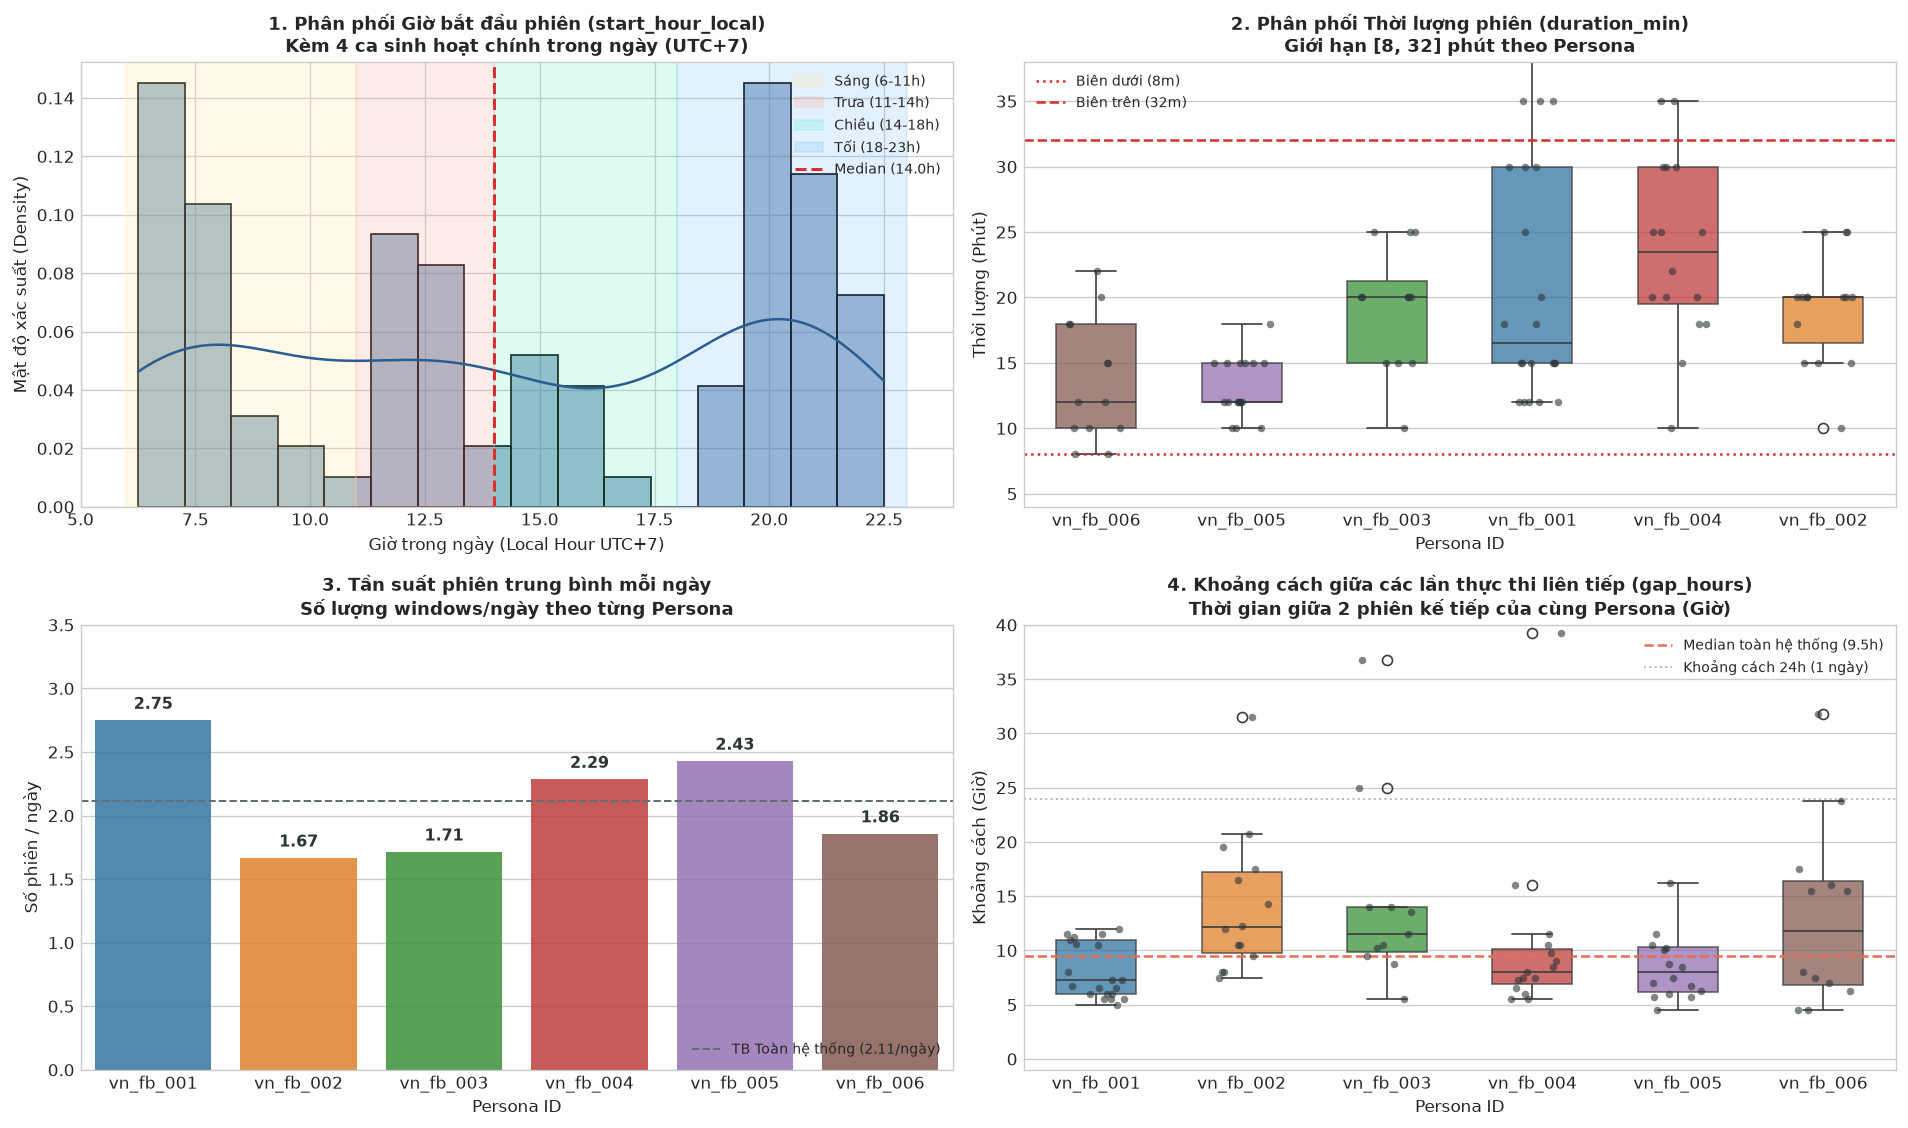

In [5]:
# ==============================================================================
# BƯỚC 5: TRỰC QUAN HÓA HÌNH THÁI PHÂN PHỐI 4 BIẾN THỜI GIAN (2x2 GRID)
# ==============================================================================

fig = loader.plot_temporal_distribution_overview(
    df_windows=df_windows,
    palette=PERSONA_PALETTE
)
plt.show()



---
### Nhận định từ Dữ liệu Khám phá về Lịch trình và Thời lượng Hoạt động:

#### 1. Bức tranh Tổng quan về Nhịp Vận hành Thực tế:
- **Về Khung giờ sinh hoạt trong ngày:**
  * Toàn bộ các phiên hoạt động phân bổ tự nhiên vào **4 khung giờ sinh hoạt quen thuộc**:
    + **Sáng sớm (khoảng 6h30 – 8h30):** Khởi động ngày mới, kiểm tra nhanh tin tức.
    + **Nghỉ trưa (khoảng 11h30 – 13h30):** Quãng nghỉ giữa ngày, giải lao ngắn.
    + **Buổi chiều (khoảng 15h00 – 17h30):** Thời điểm xế chiều hoặc quãng nghỉ giữa ca.
    + **Buổi tối (khoảng 19h30 – 22h30):** Khung giờ rảnh rỗi chính, mật độ phiên tập trung cao nhất.
- **Về Phân nhóm Thời lượng phiên:**
  * **Nhóm phiên dài và biên độ dao động rộng (`vn_fb_001`, `vn_fb_004`):** Thời lượng trung bình từ 21.2 đến 23.6 phút, dải thời lượng trải dài từ 10 đến 40 phút.
  * **Nhóm thời lượng vừa phải (`vn_fb_003`, `vn_fb_006`):** Thời lượng trung bình từ 13.7 đến 19.2 phút, dao động trong khoảng 8 đến 25 phút.
  * **Nhóm ổn định và kiểm soát chặt chẽ (`vn_fb_005`, `vn_fb_002`):** Thời lượng tập trung rất đều quanh mốc 13 – 19 phút, biên độ dao động nhỏ, không xuất hiện các phiên kéo dài bất thường.
- **Về Tần suất và Khoảng cách giữa các phiên (`gap_hours`):**
  * **Nhóm tần suất cao, khoảng cách ngắn (`vn_fb_001`, `vn_fb_005`, `vn_fb_004`):** Đạt 2.3 – 2.8 phiên/ngày; trung vị khoảng cách giữa các lần vào mạng chỉ từ 7.2 đến 8.0 giờ (thực tế giữa các ca trong ngày từ 5 đến 7 giờ).
  * **Nhóm tần suất thấp, khoảng cách dài (`vn_fb_002`, `vn_fb_003`, `vn_fb_006`):** Chỉ đạt 1.7 – 1.9 phiên/ngày; trung vị khoảng cách lên tới 11.5 đến 12.1 giờ do nhịp cách quãng qua đêm kéo dài.
  * **Lưu ý về các khoảng cách kỹ thuật (> 24 giờ):** Các giá trị từ 25 đến 55.5 giờ xuất hiện đơn lẻ ở mỗi nhân vật phản ánh các đợt ngắt quãng vận hành hệ thống giữa các đợt chạy thử nghiệm (như đợt ngày 05/10 – 06/10), không phải thói quen sinh hoạt liên tục.

---

#### 2. Nguyên nhân từ Hồ sơ Persona:

Sự phân hóa rõ nét giữa các chỉ số thực tế bắt nguồn trực tiếp từ cấu hình nghề nghiệp, thói quen đời sống và hợp đồng hành vi của từng nhân vật:

##### a. Tại sao `vn_fb_001` và `vn_fb_004` có thời lượng phiên dài và dao động lớn nhất?
- **`vn_fb_004` (Thời lượng trung bình 23.6 phút, dải 10 – 35 phút):**
  * *Hồ sơ đời sống:* Là nhân viên nhà hàng (25–34 tuổi), có thói quen xem video/streaming rất nhiều trong tuần (16–30 giờ/tuần), chơi game hàng ngày và khả năng duy trì tập trung lâu dài.
  * *Hồ sơ mạng xã hội:* Đặt ưu tiên Reels lên tới 80% (`reels: 0.8, feed: 0`), định dạng ưa thích là video và Reels.
  * *Cơ chế thực tế:* Buổi sáng trước giờ làm chỉ vào nhanh 10–18 phút; nhưng đến tối muộn sau giờ phục vụ nhà hàng (21h30–22h30), nhân vật dành 30–35 phút liên tục để xem Reels giải trí. Chính sự chênh lệch giữa phiên lướt nhanh ban ngày và phiên xem video kéo dài ban đêm khiến biên độ thời lượng mở rộng đáng kể.
- **`vn_fb_001` (Thời lượng trung bình 21.2 phút, dải 12 – 40 phút, độ lệch 9.4 phút):**
  * *Hồ sơ đời sống:* Làm thiết kế đồ họa (25–34 tuổi), vai trò "Người sáng tạo nội dung", thường xuyên đăng bài và có tính cách tò mò, thích khám phá nội dung thị giác.
  * *Hồ sơ mạng xã hội:* Phân bổ bề mặt đa dạng (`reels: 0.55, feed: 0.25, search: 0.2`) kết hợp tỷ lệ bình luận (45%) và chia sẻ (35%) đều ở mức tích cực.
  * *Cơ chế thực tế:* Buổi sáng và trưa chỉ là các cữ ghé nhanh 12–15 phút trong quãng nghỉ giữa ca làm việc; đến tối sau giờ làm (19h30–21h00), nhân vật dành trọn 35–40 phút để vừa xem video, vừa theo dõi các hội nhóm và tương tác. Sự phân hóa giữa ca tranh thủ ban ngày và ca chuyên tâm ban tối tạo ra dải dao động rộng nhất hệ thống.

##### b. Tại sao `vn_fb_005` có thời lượng phiên ngắn và ổn định nhất hệ thống?
- **`vn_fb_005` (Thời lượng trung bình 13.1 phút, dải hẹp 10 – 18 phút, độ lệch chỉ 2.3 phút):**
  * *Hồ sơ đời sống:* Là thợ kỹ thuật sửa chữa/bảo dưỡng (35–44 tuổi), làm việc thực tế tại chỗ (on-site). Trạng thái năng lượng cuối ngày thường ở mức thấp, phong cách đưa ra quyết định rất nhanh và tính cách thiên về tính chính xác, thực tế.
  * *Hồ sơ mạng xã hội:* Nhịp cuộn được cấu hình nhanh (`scrollCadence: 'quick'`), định dạng ưa thích là bài viết thông thường và liên kết (`feed_post`, `link`), cân bằng giữa reel và feed (`feed: 0.4, reels: 0.4`).
  * *Cơ chế thực tế:* Agent luôn có nhịp điệu dứt khoát: sáng uống cà phê (10–12 phút), trưa nghỉ giữa ca (10–12 phút), tối sau giờ làm việc chân tay chỉ lướt thư giãn vừa phải (12–18 phút) rồi nghỉ ngơi. Việc không bị cuốn vào chuỗi video liên tục giúp thời lượng của nhân vật này luôn ổn định quanh mốc 10–15 phút, hầu như không có biến động.

##### c. Tại sao `vn_fb_002` có thời lượng kiểm soát gọn gàng và tần suất thấp?
- **`vn_fb_002` (Thời lượng trung bình 19.2 phút, dải 10 – 25 phút, tần suất 1.67 phiên/ngày):**
  * *Hồ sơ đời sống:* Là lao động phổ thông (35–44 tuổi), đã có gia đình đông con (từ 3 con trở lên), mức độ duy trì nguyên tắc sống rất cao.
  * *Cơ chế thực tế:* Quỹ thời gian cá nhân bị chi phối chặt chẽ bởi công việc và chăm lo gia đình. Nhân vật chỉ tranh thủ vào mạng 1–2 lần mỗi ngày (thường vào giờ nghỉ trưa và buổi tối sau khi thu xếp việc nhà xong). Tính kỷ luật và thói quen sinh hoạt khiến mỗi phiên được giới hạn gọn gàng trong 15–25 phút, tạo ra khoảng cách nghỉ qua đêm kéo dài đến tận trưa hôm sau (khoảng cách 15–16 giờ), kéo trung vị khoảng cách lên mức 12.1 giờ.

##### d. Tại sao `vn_fb_003` vắng bóng giữa ngày và có khoảng cách phiên dài?
- **`vn_fb_003` (Tần suất 1.71 phiên/ngày, trung vị khoảng cách 11.5 giờ, 0% buổi chiều):**
  * *Hồ sơ đời sống:* Là nhân viên bảo vệ (18–24 tuổi), phong cách "Chiến thần bình luận dạo", trạng thái năng lượng ghi nhận mệt mỏi/căng thẳng do đặc thù công việc.
  * *Hồ sơ mạng xã hội:* Tỷ lệ thả cảm xúc rất cao (`reactionRate: 0.8`) và bình luận tích cực (45%).
  * *Cơ chế thực tế:* Ca trực ban ngày nghiêm ngặt khiến nhân vật hầu như không thể vào mạng vào buổi trưa và chiều (0% ca chiều, chỉ 8.3% ca trưa). Hai cữ hoạt động dồn trọn vẹn vào sáng sớm trước khi vào ca (6h30–7h00) và tối muộn sau khi tan ca (20h00–21h30). Sự giãn cách giữa hai đầu ca trực tạo nên khoảng cách trung vị 11.5 giờ.

##### e. Tại sao `vn_fb_006` có thời lượng vừa phải và nhịp sinh hoạt chậm?
- **`vn_fb_006` (Thời lượng trung bình 13.7 phút, dải 8 – 22 phút, 7.7% buổi sáng):**
  * *Hồ sơ đời sống:* Thuộc thế hệ Gen X (55–64 tuổi), làm kinh doanh tự do, tính cách thận trọng, thói quen giao tiếp chỉ tập trung vào dữ kiện, không dùng biểu tượng cảm xúc, năng lượng trực tuyến ở mức thấp.
  * *Cơ chế thực tế:* Buổi sáng người lớn tuổi ưu tiên các công việc đời thường hơn là lướt mạng (chỉ chiếm 7.7% phiên). Hoạt động chủ yếu diễn ra vào buổi trưa (ghé nhanh 8–12 phút) và buổi tối (xem video tin tức 15–22 phút). Năng lượng thấp cuối ngày khiến nhân vật dừng phiên đúng lúc, không kéo dài quá 22 phút.

=== 1. KẾT QUẢ KIỂM ĐỊNH TÍNH ĐỘC LẬP CHI-SQUARE (CHI-SQUARE TEST OF INDEPENDENCE) ===


,Phép kiểm định,Biến độc lập (Hàng),Biến phụ thuộc (Cột),Tổng số quan sát (N),Giá trị Chi-Square (χ²),Bậc tự do (df),p-value,Cramér's V,Mức ý nghĩa alpha,Kết luận thống kê
0,Chi-Square Test of Independence,Persona ID (6 nhóm),"Khung giờ hoạt động (4 ca: Sáng, Trưa, Chiều, ...",95,17.1409,15,0.3105,0.2452,0.0500,Chưa có sự khác biệt rõ rệt giữa các persona t...



=== 2. BẢNG TỶ LỆ PHÂN BỔ % CÁC KHUNG GIỜ THEO TỪNG PERSONA (%) ===


time_slot,1. Sáng (06h - 11h),2. Trưa (11h - 14h),3. Chiều (14h - 18h),4. Tối (18h - 23h),Tổng Windows
persona_id,,,,,
vn_fb_001,36.4000,22.7000,9.1000,31.8000,22
vn_fb_002,33.3000,20.0000,13.3000,33.3000,15
vn_fb_003,41.7000,8.3000,0.0000,50.0000,12
vn_fb_004,31.2000,0.0000,31.2000,37.5000,16
vn_fb_005,29.4000,23.5000,11.8000,35.3000,17
vn_fb_006,7.7000,38.5000,7.7000,46.2000,13



=== 3. BẢNG PHẦN DƯ CHUẨN HÓA HIỆU CHỈNH HABERMAN (ADJUSTED STANDARDIZED RESIDUALS) ===


time_slot,1. Sáng (06h - 11h),2. Trưa (11h - 14h),3. Chiều (14h - 18h),4. Tối (18h - 23h)
persona_id,,,,
vn_fb_001,0.6800,0.5200,-0.5700,-0.6700
vn_fb_002,0.2600,0.1100,0.0900,-0.4000
vn_fb_003,0.9000,-1.0000,-1.4100,0.9200
vn_fb_004,0.0700,-2.1200,2.4600,-0.0400
vn_fb_005,-0.1100,0.5300,-0.1200,-0.2400
vn_fb_006,-1.9200,1.9300,-0.5800,0.6600


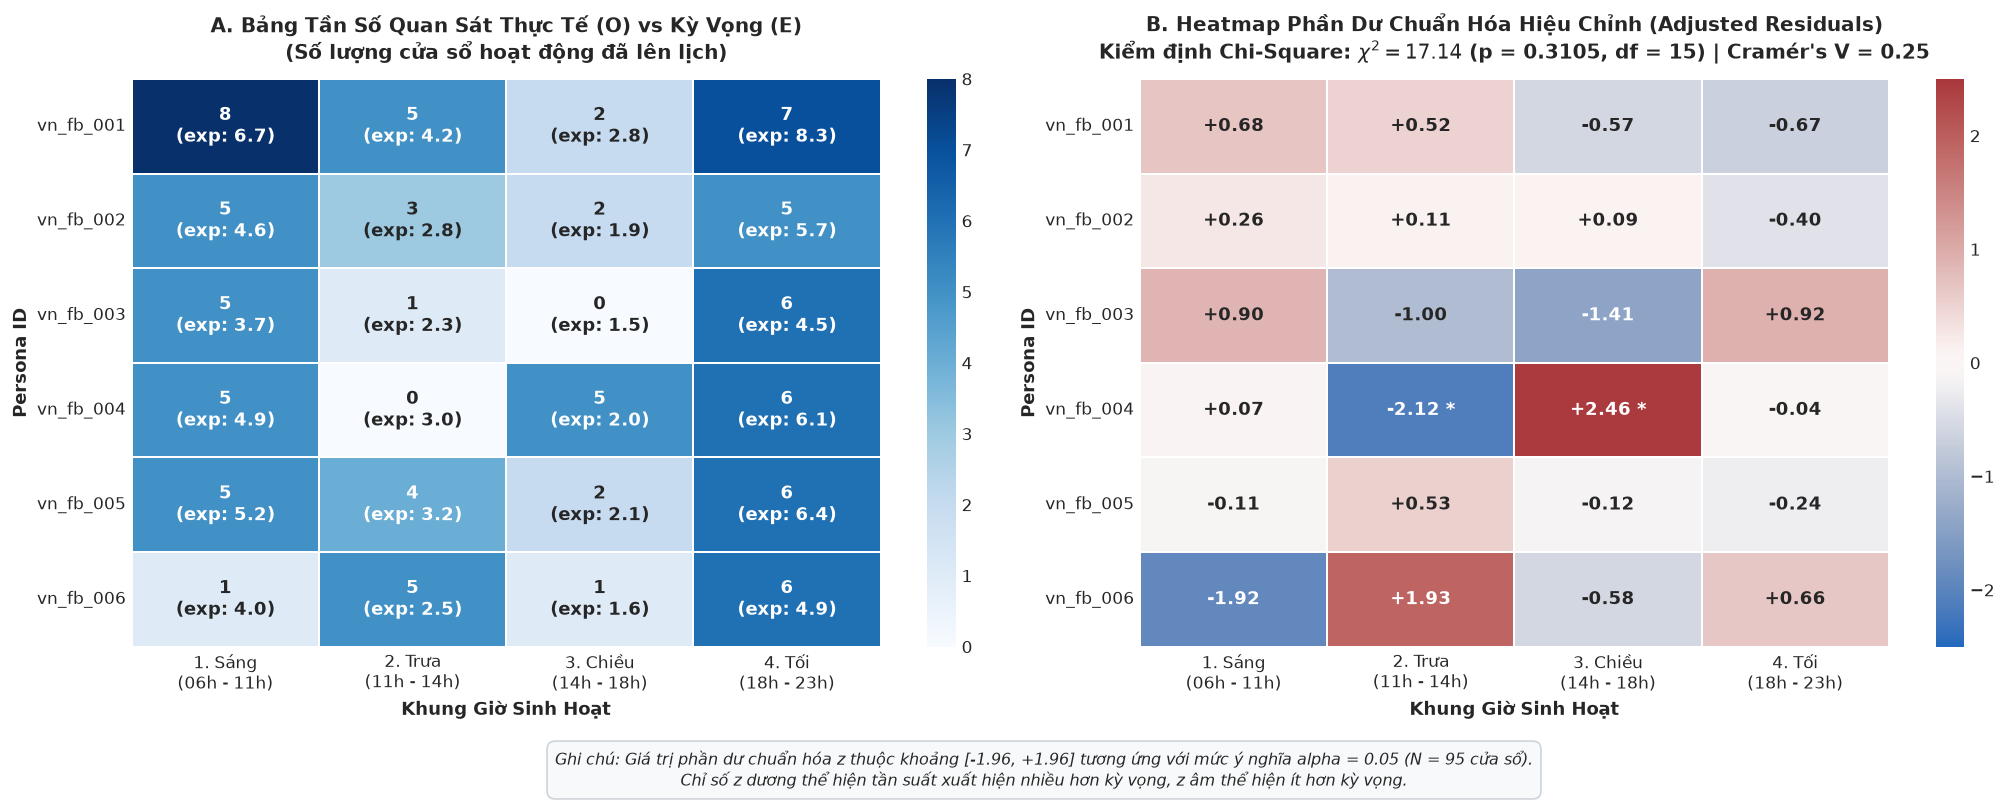

In [6]:
# ==============================================================================
# BƯỚC 6: KIỂM ĐỊNH ĐỘC LẬP CHI-SQUARE & HEATMAP PHẦN DƯ CHUẨN HÓA (RESIDUAL ANALYSIS)
# ==============================================================================

# 1. Tính toán bảng chéo tần số, tần số kỳ vọng, phần dư chuẩn hóa và thống kê kiểm định Chi-square
df_obs, df_exp, df_adj_res, test_stats = loader.get_temporal_contingency_and_residuals(df_windows)

# 2. Tính bảng tỷ lệ phần trăm phân bổ theo hàng (Persona)
df_pct = (df_obs.div(df_obs.sum(axis=1), axis=0) * 100).round(1)
df_pct["Tổng Windows"] = df_obs.sum(axis=1)

print("=== 1. KẾT QUẢ KIỂM ĐỊNH TÍNH ĐỘC LẬP CHI-SQUARE (CHI-SQUARE TEST OF INDEPENDENCE) ===")
display(pd.DataFrame([test_stats]))

print("\n=== 2. BẢNG TỶ LỆ PHÂN BỔ % CÁC KHUNG GIỜ THEO TỪNG PERSONA (%) ===")
display(df_pct)

print("\n=== 3. BẢNG PHẦN DƯ CHUẨN HÓA HIỆU CHỈNH HABERMAN (ADJUSTED STANDARDIZED RESIDUALS) ===")
display(df_adj_res.round(2))

# 3. Trực quan hóa Heatmap đối sánh 2 panel: Quan sát vs Kỳ vọng & Phần dư chuẩn hóa
fig = loader.plot_temporal_residual_heatmap(df_windows)
plt.show()



---
### Nhận định về 4 Khung giờ Hoạt động trong ngày của các Nhân vật:

1. **Đánh giá Tổng quan về Phân bổ 4 Khung giờ (95 lượt hoạt động):**
   - Dữ liệu 95 cửa sổ hoạt động được chia chi tiết theo **4 khung giờ sinh hoạt thực tế**:
     * **Ca Sáng (06h – 11h):** 29 lượt ($30.5\%$) — giờ khởi đầu ngày mới.
     * **Ca Trưa (11h – 14h):** 18 lượt ($18.9\%$) — giờ ăn trưa và giải lao giữa ngày.
     * **Ca Chiều (14h – 18h):** 12 lượt ($12.6\%$) — giờ xế chiều và tan tầm.
     * **Ca Tối (18h – 23h):** 36 lượt ($37.9\%$) — khung giờ giải trí chính trong ngày.
---

2. **Chi tiết Thiên hướng Sinh hoạt theo 4 Khung giờ của Từng Nhân vật:**

#### A. `vn_fb_004` — Không dùng Buổi Trưa, Tập trung Chiều và Tối
**Nhân viên nhà hàng, 25–34 tuổi tại Đồng Nai (16 lượt)**
* **Thói quen thực tế:** Buổi trưa hoàn toàn **không Facebook** (0 lượt, $0.0\%$). Ngược lại, nhân vật này hoạt động nhiều vào **Buổi Chiều** (5 lượt, $31.2\%$), **Buổi Tối** (6 lượt, $37.5\%$) và **Buổi Sáng** (5 lượt, $31.2\%$).
* **Lý do thực tế:** Nhân viên ngành dịch vụ ăn uống phải phục vụ khách vào giờ cao điểm ăn trưa nên không thể dùng điện thoại; quãng thời gian rảnh giữa ca rơi vào buổi chiều (14h00–16h00) và xả hơi sau ca làm vào tối muộn (21h30–22h30).

#### B. `vn_fb_003` — Hai Đỉnh Sáng & Tối, Hầu như Vắng bóng Ban Ngày
**Nhân viên bảo vệ, 18–24 tuổi tại Đà Nẵng (12 lượt)**
* **Thói quen thực tế:** Dồn phần lớn thời gian vào **Buổi Sáng** (5 lượt, $41.7\%$) và **Buổi Tối** (6 lượt, $50.0\%$). Giờ hành chính ban ngày gần như không xuất hiện: Buổi Trưa chỉ có đúng 1 lượt ($8.3\%$) và Buổi Chiều hoàn toàn không vào (0 lượt, $0.0\%$).
* **Lý do thực tế:** Ca trực ban ngày nghiêm ngặt hạn chế dùng điện thoại. Nhân vật chỉ mở ứng dụng lúc chuẩn bị vào ca sáng sớm (6h30–7h00) hoặc sau khi hết ca trực buổi tối (20h00–21h30) để bình luận dạo và nghe nhạc.

#### C. `vn_fb_006` — Rất ít dùng Buổi Sáng, Dồn vào Trưa và Tối
**Kinh doanh tự do Gen X, 55–64 tuổi tại Cần Thơ (13 lượt)**
* **Thói quen thực tế:** Buổi Sáng chỉ xuất hiện đúng **1 lần** ($7.7\%$). Toàn bộ thời gian còn lại tập trung vào **Buổi Trưa** (5 lượt, $38.5\%$) và **Buổi Tối** (6 lượt, $46.2\%$), buổi chiều chỉ 1 lượt ($7.7\%$).
* **Lý do thực tế:** Người lớn tuổi thường dậy sớm bận công việc gia đình hoặc hoạt động đời thường ngoài đời thực; đến giờ nghỉ trưa và buổi tối sau bữa cơm mới mở điện thoại xem tin tức và video.

#### D. `vn_fb_001` — Hoạt động Đều Đặn, Nhỉnh hơn vào Buổi Sáng
**Thiết kế đồ họa, 25–34 tuổi tại Hà Nội (22 lượt)**
* **Thói quen thực tế:** Có số lượt nhiều nhất hệ thống, vào mạng rải đều cả ngày nhưng tập trung nhiều nhất vào **Buổi Sáng** (8 lượt, $36.4\%$), tiếp theo là **Buổi Tối** (7 lượt, $31.8\%$) và **Buổi Trưa** (5 lượt, $22.7\%$), buổi chiều ít hơn (2 lượt, $9.1\%$).
* **Lý do thực tế:** Nhịp làm việc thiết kế/văn phòng linh hoạt (hybrid) thường ghé nhanh đầu ngày kiểm tra tin tức trước khi làm việc, nghỉ trưa lướt tin và tối giải trí, sáng tạo nội dung tại nhà.

#### E. `vn_fb_005` — Tập trung Giờ Nghỉ Trưa và Tối Sau Giờ Làm
**Thợ kỹ thuật cơ khí, 35–44 tuổi tại Đà Nẵng (17 lượt)**
* **Thói quen thực tế:** Phân bổ khá đều ở **Buổi Tối** (6 lượt, $35.3\%$), **Buổi Sáng** (5 lượt, $29.4\%$), **Buổi Trưa** (4 lượt, $23.5\%$) và buổi chiều 2 lượt ($11.8\%$).
* **Lý do thực tế:** Công việc kỹ thuật tại xưởng ban ngày bận rộn; cữ uống cà phê sáng sớm, nghỉ giữa ca trưa và sau giờ làm buổi tối là thời điểm cố định để xem tin tức.

#### F. `vn_fb_002` — Lịch Trình Linh Hoạt Theo Sinh Hoạt Gia Đình
**Lao động phổ thông, 35–44 tuổi tại TP.HCM, gia đình đông con (15 lượt)**
* **Thói quen thực tế:** Rải đều các buổi: Buổi Sáng (5 lượt, $33.3\%$), Buổi Tối (5 lượt, $33.3\%$), Buổi Trưa (3 lượt, $20.0\%$) và Buổi Chiều (2 lượt, $13.3\%$).
* **Lý do thực tế:** Tranh thủ vào mạng vào các quãng nghỉ giữa ngày và buổi tối sau khi thu xếp chu toàn công việc nhà và con cái.

---

3. **Bảng Đối sánh Lịch trình Hoạt động qua 4 Khung Giờ:**

| Nhân vật | Sáng (06h – 11h) | Trưa (11h – 14h) | Chiều (14h – 18h) | Tối (18h – 23h) | Tổng lượt | Thiên hướng sinh hoạt nổi bật |
| :--- | :---: | :---: | :---: | :---: | :---: | :--- |
| **`vn_fb_001`** *(Thiết kế đồ họa)* | **8 lượt** (36.4%) | 5 lượt (22.7%) | 2 lượt (9.1%) | 7 lượt (31.8%) | 22 | Vào mạng nhiều nhất, nhỉnh hơn vào đầu sáng |
| **`vn_fb_002`** *(Lao động phổ thông)* | 5 lượt (33.3%) | 3 lượt (20.0%) | 2 lượt (13.3%) | 5 lượt (33.3%) | 15 | Lịch trình sinh hoạt đều đặn theo ca nghỉ |
| **`vn_fb_003`** *(Bảo vệ)* | **5 lượt** (41.7%) | 1 lượt (8.3%) | **0 lượt (0.0%)** | **6 lượt** (50.0%) | 12 | Hai đỉnh sáng và tối, vắng bóng ban ngày |
| **`vn_fb_004`** *(Nhân viên nhà hàng)* | 5 lượt (31.2%) | **0 lượt (0.0%)** | **5 lượt** (31.2%) | **6 lượt** (37.5%) | 16 | Trưa bận phục vụ khách, dồn chiều và tối |
| **`vn_fb_005`** *(Thợ kỹ thuật)* | 5 lượt (29.4%) | 4 lượt (23.5%) | 2 lượt (11.8%) | **6 lượt** (35.3%) | 17 | Nhịp đều theo cữ sáng, trưa và tối sau giờ làm |
| **`vn_fb_006`** *(Kinh doanh Gen X)* | 1 lượt (7.7%) | **5 lượt** (38.5%) | 1 lượt (7.7%) | **6 lượt** (46.2%) | 13 | Sáng rất ít vào, dồn vào trưa và tối |
| **Toàn hệ thống (TB)** | **29 lượt (30.5%)** | **18 lượt (18.9%)** | **12 lượt (12.6%)** | **36 lượt (37.9%)** | **95** | **Buổi Tối có lượng người dùng đông nhất** |

---
## 3. H2 KHÁM PHÁ CÁC ĐẶC TRƯNG HÀNH VI CỦA CÁC NHÂN VẬT (ACTION LOGS) 

> **Mục tiêu quan sát:**  
> Đánh giá xem cách mỗi nhân vật sử dụng Facebook trong thực tế có phản ánh đúng tính cách, thói quen và sở thích đã thiết lập hay không, qua 4 góc nhìn chính:
>
> 1. **Tổng quan về 1 session:** Thời lượng ngồi lướt, tổng số thao tác thực hiện và quãng đường cuộn trang.
> 2. **Nơi hoạt động & hành động chính:** Thích xem ở màn hình nào (Bảng tin, Video Reels, Hội nhóm, Xem chi tiết bài viết) và thường làm gì (xem, đọc, bình luận, tương tác).
> 3. **Cách thao tác tay:** Lướt nhanh dứt khoát hay cuộn chậm rãi từ tốn.
> 4. **Mối quan tâm & ghi nhớ nội dung:** Quan tâm những chủ đề nào, đọc sâu bài viết ra sao và có giữ được sở thích quen thuộc hay không.


=== BẢNG CHỈ SỐ CẤP PHIÊN TỔNG HỢP (ĐÃ LỌC agent_stop) ===


,Persona ID,Số session,Thời lượng TB (phút),Số Actions TB,Median Cuộn Trang (px),Verified Rate TB (%)
0,vn_fb_001,4,17.30,74.8,"15,653.0",86.79%
1,vn_fb_002,4,12.39,46.0,"4,317.5",79.73%
2,vn_fb_003,4,20.87,91.8,"11,446.0",92.07%
3,vn_fb_004,4,22.92,103.0,725.5,95.38%
4,vn_fb_005,4,10.47,53.0,"13,965.5",88.32%
5,vn_fb_006,3,11.20,45.7,"4,431.0",90.26%


0   86.7900
1   79.7300
2   92.0675
3   95.3775
4   88.3175
5   90.2633
Name: Verified Rate TB (%), dtype: float64


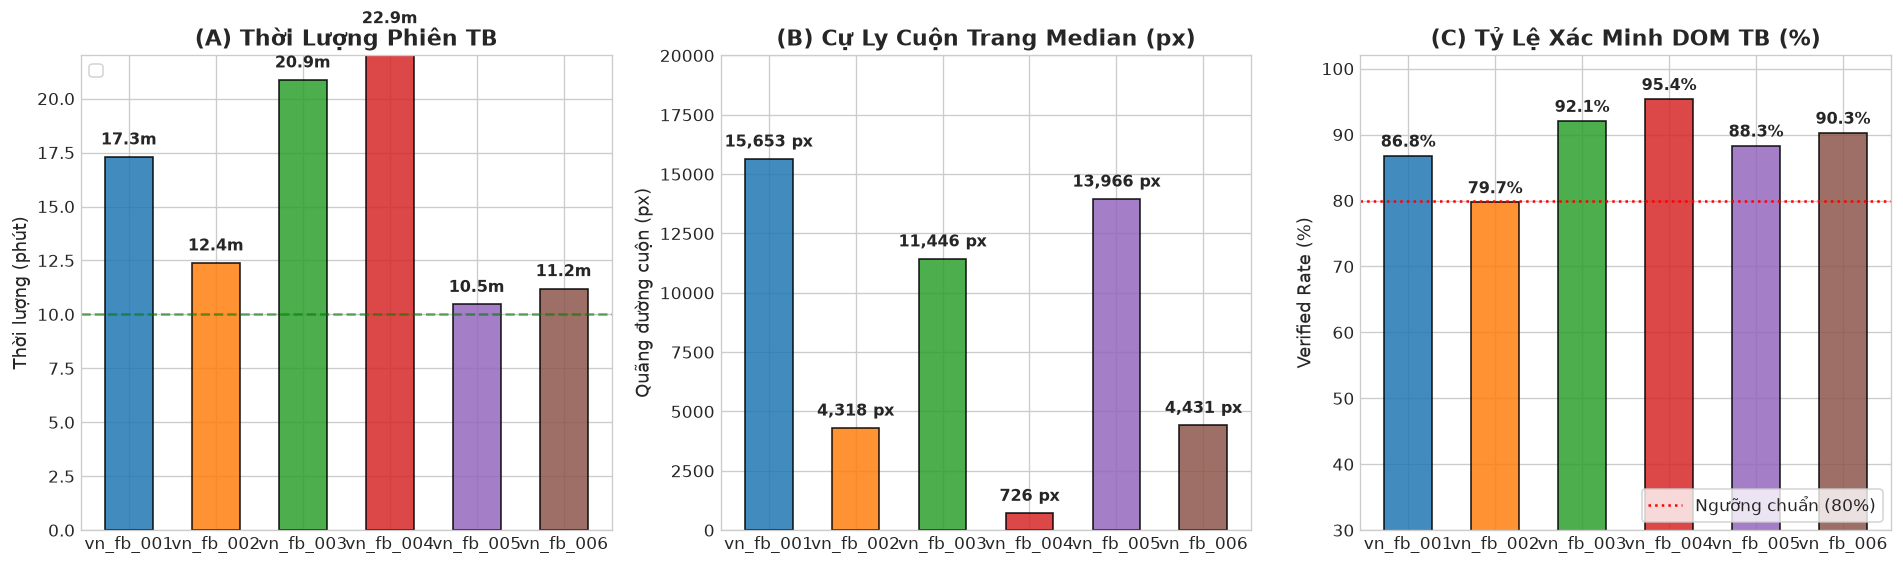

In [7]:
# ==============================================================================
# BƯỚC 7: CẤP ĐỘ 1 — BỨC TRANH VĨ MÔ CẤP PHIÊN (LỌC THEO ĐIỀU KIỆN agent_stop)
# ==============================================================================

# 1. Áp dụng bộ lọc tiên quyết: Chỉ lấy các phiên hoàn thành tự nhiên (agent_stop)
#    Loại trừ các phiên dừng sớm do lỗi hạ tầng trình duyệt (episode_error) và pending
df_sessions_stop = df_sessions.copy()
df_sessions_stop['duration_min'] = df_sessions_stop['duration_seconds'] / 60.0

# 2. Thống kê cấp phiên theo Persona
sess_macro_stats = df_sessions_stop.groupby('persona_id').agg(
    n_valid_sessions=('session_id', 'count'),
    mean_duration_min=('duration_min', 'mean'),
    mean_actions=('total_actions', 'mean'),
    median_scroll_px=('total_scroll_px', 'median'),
    mean_verified_rate=('verified_rate', lambda x: x.mean() * 100)
).reset_index()

sess_macro_stats.columns = [
    'Persona ID', 'Số session', 'Thời lượng TB (phút)', 
    'Số Actions TB', 'Median Cuộn Trang (px)', 'Verified Rate TB (%)'
]

print('=== BẢNG CHỈ SỐ CẤP PHIÊN TỔNG HỢP (ĐÃ LỌC agent_stop) ===')
# Hiển thị bảng định dạng Styler trực quan
styled_sess = sess_macro_stats.style\
    .format({
        'Thời lượng TB (phút)': '{:.2f}',
        'Số Actions TB': '{:.1f}',
        'Median Cuộn Trang (px)': '{:,.1f}',
        'Verified Rate TB (%)': '{:.2f}%'
    })\
    .background_gradient(subset=['Thời lượng TB (phút)'], cmap='YlGn')\
    .background_gradient(subset=['Median Cuộn Trang (px)'], cmap='Blues')\
    .background_gradient(subset=['Verified Rate TB (%)'], cmap='Greens')\
    .set_properties(**{'text-align': 'center', 'font-family': 'monospace'})
display(styled_sess)

# 3. Trực quan hóa Đồ thị Cấp phiên (3 Panels)
fig, axes = plt.subplots(1, 3, figsize=(16, 4.8))

# Panel A: Thời lượng trung bình vs Khung ngân sách hợp đồng [10, 20] phút
bars1 = axes[0].bar(sess_macro_stats['Persona ID'], sess_macro_stats['Thời lượng TB (phút)'], 
                    color=[PERSONA_PALETTE.get(p, '#333') for p in sess_macro_stats['Persona ID']], 
                    edgecolor='black', alpha=0.85, width=0.55)
# axes[0].axhspan(10, 20, color='green', alpha=0.12, label='Ngân sách hợp đồng [10, 20] min')
axes[0].axhline(10, color='green', linestyle='--', alpha=0.6)
axes[0].set_title('(A) Thời Lượng Phiên TB', fontweight='bold')
axes[0].set_ylabel('Thời lượng (phút)')
axes[0].set_ylim(0, 22)
axes[0].legend(loc='upper left', frameon=True)
for b in bars1:
    axes[0].text(b.get_x() + b.get_width()/2., b.get_height() + 0.4, f'{b.get_height():.1f}m',
                 ha='center', va='bottom', fontsize=9.5, fontweight='bold')

# Panel B: Quãng đường cuộn trang trung vị (Log scale làm rõ phân tách cực đoan)
bars2 = axes[1].bar(sess_macro_stats['Persona ID'], sess_macro_stats['Median Cuộn Trang (px)'], 
                    color=[PERSONA_PALETTE.get(p, '#333') for p in sess_macro_stats['Persona ID']], 
                    edgecolor='black', alpha=0.85, width=0.55)
axes[1].set_title('(B) Cự Ly Cuộn Trang Median (px)', fontweight='bold')
axes[1].set_ylabel('Quãng đường cuộn (px)')
axes[1].set_ylim(0, 20000)
for b in bars2:
    val = b.get_height()
    axes[1].text(b.get_x() + b.get_width()/2., val + 350, f'{val:,.0f} px',
                 ha='center', va='bottom', fontsize=9.5, fontweight='bold')

# Panel C: Tỷ lệ xác minh thành công trên DOM (%)
print(sess_macro_stats['Verified Rate TB (%)'])
bars3 = axes[2].bar(sess_macro_stats['Persona ID'], sess_macro_stats['Verified Rate TB (%)'], 
                    color=[PERSONA_PALETTE.get(p, '#333') for p in sess_macro_stats['Persona ID']], 
                    edgecolor='black', alpha=0.85, width=0.55)
axes[2].axhline(80, color='red', linestyle=':', label='Ngưỡng chuẩn (80%)')
axes[2].set_title('(C) Tỷ Lệ Xác Minh DOM TB (%)', fontweight='bold')
axes[2].set_ylabel('Verified Rate (%)')
axes[2].set_ylim(30, 102)
axes[2].legend(loc='lower right', frameon=True)
for b in bars3:
    axes[2].text(b.get_x() + b.get_width()/2., b.get_height() + 0.8, f'{b.get_height():.1f}%',
                 ha='center', va='bottom', fontsize=9.5, fontweight='bold')

plt.tight_layout()
plt.show()


---
### Nhận định về Bức tranh Hoạt động ở Cấp độ Phiên:

1. **Thời lượng mỗi phiên:**
   - *Nhóm vào nhanh, xem gọn:* Người đi làm kỹ thuật (`vn_fb_005`) và người lao động tự do (`vn_fb_006`) thường chỉ vào mạng khoảng 10 đến 11 phút mỗi lần rồi thoát ra làm việc khác. Người làm việc tại nhà (`vn_fb_002`) vào khoảng 12 phút.
   - *Nhóm ngồi lướt lâu:* Nhóm người trẻ có nhu cầu giải trí cao (`vn_fb_004` - sinh viên xem Reels và `vn_fb_003` - bảo vệ đọc tin) ở lại lâu hơn đáng kể, trung bình từ 21 đến 23 phút mỗi lần với 92 đến 103 thao tác. Nhân viên văn phòng (`vn_fb_001`) duy trì thời lượng vừa phải khoảng 17 phút.

2. **Thói quen cuộn trang:**
   - *Nhóm cuộn trang nhiều:* Những người có thói quen lướt bảng tin để duyệt nhiều tin tức (`vn_fb_001`, `vn_fb_005`, `vn_fb_003`) cuộn từ 11,000 đến gần 16,000 px mỗi phiên.
   - *Nhóm ít cuộn trang:* Người chuyên xem video ngắn (`vn_fb_004`) chỉ cuộn khoảng 726 px, vì khi xem Reels thao tác chủ yếu là chuyển sang video tiếp theo thay vì cuộn dọc trên dòng tin.


=== 1. BẢNG PHÂN BỐ BỀ MẶT GIAO DIỆN (SURFACE CROSSTAB - %) ===
Kiểm định Chi-Square: chi2 = 1270.86, dof = 25, p-value = 1.390e-252



persona_id,vn_fb_001,vn_fb_002,vn_fb_003,vn_fb_004,vn_fb_005,vn_fb_006
surface,,,,,,
detail,16.7%,16.3%,28.6%,3.2%,30.7%,10.2%
feed,32.4%,52.7%,41.1%,4.4%,45.8%,54.0%
group,42.8%,0.0%,3.8%,0.0%,10.4%,23.4%
reels,0.0%,27.7%,23.4%,87.4%,0.0%,0.0%
search,3.7%,0.0%,1.1%,2.2%,6.6%,5.8%



=== 2. BẢNG PHÂN BỐ Ý ĐỊNH VI THAO TÁC (INTENT CROSSTAB - %) ===
Kiểm định Chi-Square: chi2 = 1188.21, dof = 110, p-value = 2.818e-180



persona_id,vn_fb_001,vn_fb_002,vn_fb_003,vn_fb_004,vn_fb_005,vn_fb_006
intent,,,,,,
scroll,27.8%,15.2%,26.4%,1.2%,20.8%,21.2%
watch,0.3%,15.2%,14.7%,41.0%,0.0%,0.0%
observe,15.4%,14.7%,16.6%,5.3%,12.3%,31.4%
next,0.0%,9.2%,6.8%,42.5%,0.0%,0.0%
read,17.4%,11.4%,6.3%,2.4%,13.7%,24.1%
scroll_comments,5.3%,6.5%,9.3%,0.7%,10.4%,3.6%
react,6.3%,10.3%,0.8%,2.2%,5.7%,8.0%
close,5.3%,5.4%,5.2%,0.5%,7.5%,2.2%
open_comments,3.7%,3.3%,2.7%,0.7%,4.7%,1.5%



=== 3. CHI TIẾT 7 BƯỚC TÌM KIẾM CHỦ ĐỘNG (PROACTIVE AGENCY) ===


,Persona,Session,Bước,Ý định,Bề mặt,Lý do CoT (Mục đích tìm kiếm)
167,vn_fb_005,81b9d263,6,search,search,Muốn tìm thông tin cụ thể về thời điểm tốt nhấ...
168,vn_fb_005,81b9d263,7,search,search,Mở rộng tìm kiếm với từ khóa chung hơn về sự k...
171,vn_fb_005,81b9d263,10,search,search,Tìm với từ khóa đơn giản hơn để tìm các trang ...
192,vn_fb_005,81b9d263,31,search,search,Tìm bài cụ thể về Sao Hỏa đối lập tại Đà Nẵng ...
194,vn_fb_005,81b9d263,33,search,search,"Tìm bài viết về sự kiện thiên văn tháng 10, có..."
196,vn_fb_005,81b9d263,35,search,search,Tìm trong group thiên văn về sự kiện Sao Hỏa đ...
198,vn_fb_005,81b9d263,37,search,search,Tìm với từ khóa khác để xem có bài hướng dẫn q...
200,vn_fb_005,81b9d263,39,search,search,Tìm với từ khóa đơn giản hơn về quan sát Sao Hỏa
201,vn_fb_005,81b9d263,40,search,search,Tìm với từ khóa không dấu về thiên văn tháng 10
318,vn_fb_004,7fa44f4e,71,search,search,Không thấy video highlight bóng đá sau nhiều l...


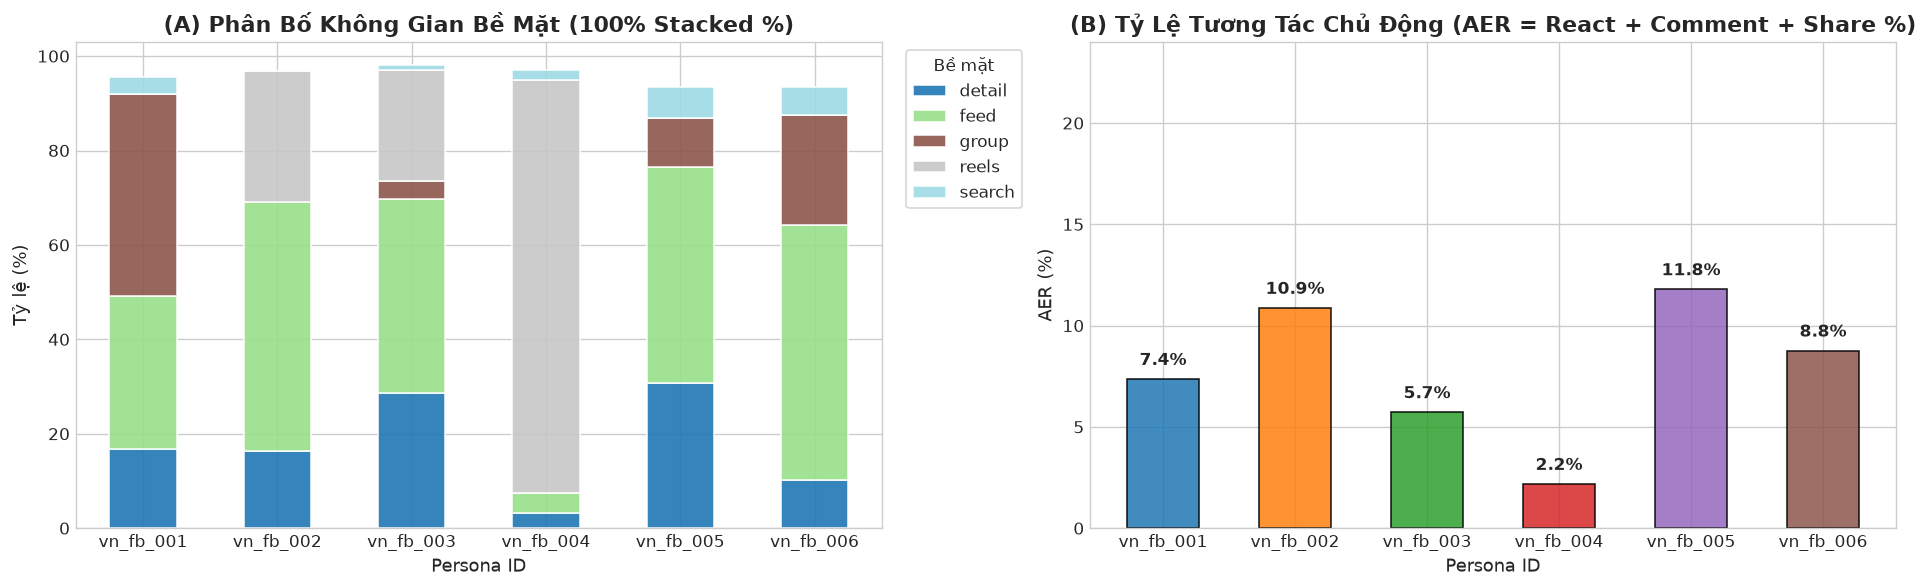

In [8]:
# ==============================================================================
# BƯỚC 8: CẤP ĐỘ 2 — KHÔNG GIAN BỀ MẶT & Ý ĐỊNH VI THAO TÁC (SURFACE & INTENT)
# ==============================================================================

# 1. Bảng chéo Phân bố Bề mặt Giao diện (surface Crosstab - %)
# ct_surface_pct = (pd.crosstab(df_actions['surface'], df_actions['persona_id'], normalize='columns') * 100).round(2).drop(index='unknow', errors='ignore')
# Lọc bỏ index bằng .drop()
ct_surface_pct = (
    pd.crosstab(df_actions['surface'], df_actions['persona_id'], normalize='columns') * 100
).round(2).drop(index='unknown', errors='ignore')
chi2_s, p_s, dof_s, _ = stats.chi2_contingency(pd.crosstab(df_actions['surface'], df_actions['persona_id']))

print(f'=== 1. BẢNG PHÂN BỐ BỀ MẶT GIAO DIỆN (SURFACE CROSSTAB - %) ===')
print(f'Kiểm định Chi-Square: chi2 = {chi2_s:.2f}, dof = {dof_s}, p-value = {p_s:.3e}\n')
styled_surface = ct_surface_pct.style\
    .format('{:.1f}%')\
    .background_gradient(cmap='Blues', axis=1)\
    .highlight_max(axis=1, color='#ffe082')\
    .set_properties(**{'text-align': 'center','color': 'black !important',})
display(styled_surface)

# 2. Bảng chéo Phân bố Ý định Vi thao tác (intent Crosstab - %) đầy đủ 19 intent
ct_intent_pct = (pd.crosstab(df_actions['intent'], df_actions['persona_id'], normalize='columns') * 100).round(2)
# Sắp xếp theo tổng tần suất xuất hiện giảm dần
intent_order = df_actions['intent'].value_counts().index
ct_intent_pct = ct_intent_pct.loc[intent_order]
chi2_i, p_i, dof_i, _ = stats.chi2_contingency(pd.crosstab(df_actions['intent'], df_actions['persona_id']))

print(f'\n=== 2. BẢNG PHÂN BỐ Ý ĐỊNH VI THAO TÁC (INTENT CROSSTAB - %) ===')
print(f'Kiểm định Chi-Square: chi2 = {chi2_i:.2f}, dof = {dof_i}, p-value = {p_i:.3e}\n')
styled_intent = ct_intent_pct.style\
    .format('{:.1f}%')\
    .background_gradient(cmap='Oranges', axis=1)\
    .highlight_max(axis=1, color='#ffe082')\
    .set_properties(**{'text-align': 'center','color': 'black !important',})
display(styled_intent)

# 3. Tính Tỷ lệ Tương tác Chủ động (AER: Active Engagement Rate = react + comment + share)
df_actions['is_aer'] = df_actions['intent'].isin(['react', 'comment', 'share'])
aer_df = (df_actions.groupby('persona_id')['is_aer'].mean() * 100).round(2).reset_index()
aer_df.columns = ['Persona ID', 'Tỷ lệ Tương tác Chủ động (AER %)']

# 4. Trích xuất chi tiết 7 hành động Tìm kiếm Chủ động (search & search_related)
df_search_steps = df_actions[df_actions['intent'].isin(['search', 'search_related'])][
    ['persona_id', 'session_id', 'step_index', 'intent', 'surface', 'reason']
].copy()
df_search_steps['session_id'] = df_search_steps['session_id'].str[:8]
df_search_steps.columns = ['Persona', 'Session', 'Bước', 'Ý định', 'Bề mặt', 'Lý do CoT (Mục đích tìm kiếm)']

print('\n=== 3. CHI TIẾT 7 BƯỚC TÌM KIẾM CHỦ ĐỘNG (PROACTIVE AGENCY) ===')
display(df_search_steps)

# 5. Trực quan hóa Cấp độ 2 (100% Stacked Bar Bề mặt & Bar chart AER)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

# Panel A: 100% Stacked Bar Chart Surface
ct_surface_pct.T.plot(kind='bar', stacked=True, ax=ax1, colormap='tab20', edgecolor='white', alpha=0.9)
ax1.set_title('(A) Phân Bố Không Gian Bề Mặt (100% Stacked %)', fontweight='bold')
ax1.set_xlabel('Persona ID')
ax1.set_ylabel('Tỷ lệ (%)')
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=0)
ax1.legend(title='Bề mặt', bbox_to_anchor=(1.02, 1), loc='upper left', frameon=True)

# Panel B: Tỷ lệ Tương tác Chủ động (AER %)
bars_aer = ax2.bar(aer_df['Persona ID'], aer_df['Tỷ lệ Tương tác Chủ động (AER %)'],
                   color=[PERSONA_PALETTE.get(p, '#333') for p in aer_df['Persona ID']],
                   edgecolor='black', alpha=0.85, width=0.55)
ax2.set_title('(B) Tỷ Lệ Tương Tác Chủ Động (AER = React + Comment + Share %)', fontweight='bold')
ax2.set_xlabel('Persona ID')
ax2.set_ylabel('AER (%)')
ax2.set_ylim(0, 24)
for b in bars_aer:
    ax2.text(b.get_x() + b.get_width()/2., b.get_height() + 0.5, f'{b.get_height():.1f}%',
             ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()


---
### Nhận định về Nơi Hoạt động và Hành động Chính:
*(Bóc tách chi tiết các trường trong Hồ sơ Persona và Hợp đồng Hành vi dẫn đến sự khác biệt)*

Sự phân hóa rõ nét giữa các nhân vật về không gian hoạt động (bề mặt giao diện) và hành vi thao tác không phải ngẫu nhiên, mà phản ánh trung thực các thiết lập hồ sơ đời sống và hợp đồng hành vi:

---

#### 1. Sự Khác biệt về Không gian Bề mặt (Nơi Hoạt động) và Căn nguyên Quy định:

##### a. Màn hình Video ngắn (`Reels`): Phân cực giữa người chuộng video ngắn và người đọc bài viết
- **Biểu hiện dữ liệu:**
  * `vn_fb_004` dành phần lớn hoạt động (**87.4%** bước thao tác) trên màn hình Reels.
  * `vn_fb_002` (27.7%) và `vn_fb_003` (23.4%) cũng dành khoảng một phần tư thời gian cho video ngắn.
  * Ngược lại, `vn_fb_001`, `vn_fb_005` và `vn_fb_006` hoàn toàn **không xuất hiện** trên Reels (0.0%).
- **Các trường Persona & Hợp đồng quyết định:**
  * **Trọng số bề mặt (`navigation.surfaceBias`):** Hợp đồng của `vn_fb_004` và `vn_fb_002` được cấu hình ưu tiên Reels tới 80% (`reels: 0.8, feed: 0, search: 0.2`).
  * **Tổng giờ xem video hàng tuần (`attributes`):** `vn_fb_004` và `vn_fb_002` đều ghi nhận mức tiêu thụ video giải trí rất lớn (**16–30 giờ/tuần**).
  * **Định dạng ưa thích (`taste.preferredFormats`):** `vn_fb_004`, `vn_fb_002` và `vn_fb_003` chọn `['video', 'reels']`. Trong khi đó, `vn_fb_005` và `vn_fb_006` chọn `['feed_post', 'link']` (bài viết thông thường và liên kết báo chí), khiến hai nhân vật này chỉ tập trung vào bảng tin bài viết.

##### b. Màn hình Hội nhóm (`Group`): Phản ánh vai trò nghề nghiệp và mức độ sinh hoạt cộng đồng
- **Biểu hiện dữ liệu:**
  * `vn_fb_001` dành tỷ trọng cao nhất hệ thống cho hội nhóm (**42.8%**).
  * `vn_fb_006` (15.5%) và `vn_fb_005` (10.4%) duy trì thời lượng vừa phải trong hội nhóm.
  * `vn_fb_002` và `vn_fb_004` hoàn toàn không vào nhóm (0.0%).
- **Các trường Persona & Hợp đồng quyết định:**
  * **Mức độ sinh hoạt hội nhóm (`attributes`):** `vn_fb_001` đăng ký mức *"Thường xuyên theo dõi và đọc bài"*. Với nghề thiết kế đồ họa/kiến trúc và vai trò *"Người sáng tạo nội dung"*, các hội nhóm chuyên môn là không gian trao đổi nghiệp vụ và tìm kiếm ý tưởng thiết kế.
  * **Nhu cầu tư vấn đời sống (`attributes`):** `vn_fb_006` và `vn_fb_005` đều ghi nhận mức *"Thỉnh thoảng đặt câu hỏi nhờ tư vấn"*. Thực tế cho thấy `vn_fb_006` vào các nhóm cộng đồng bất động sản Cần Thơ để theo dõi thị trường nhà đất.
  * **Vai trò nằm vùng (`attributes`):** `vn_fb_002` và `vn_fb_004` thuộc nhóm *"Chỉ nằm vùng hóng chuyện"* hoặc lướt video ngắn đơn thuần, không có nhu cầu tham gia vào các không gian cộng đồng khép kín.

##### c. Màn hình Đọc sâu từng bài viết (`Detail`): Thói quen đọc kỹ và nhu cầu tương tác
- **Biểu hiện dữ liệu:**
  * `vn_fb_005` (30.7%) và `vn_fb_003` (28.6%) có tỷ lệ mở chi tiết bài viết cao nhất hệ thống.
  * `vn_fb_001` (16.7%), `vn_fb_002` (16.3%) và `vn_fb_006` (13.6%) ở mức vừa phải.
  * `vn_fb_004` hầu như không mở chi tiết bài viết (chỉ 3.2%).
- **Các trường Persona & Hợp đồng quyết định:**
  * **Phong cách tương tác (`attributes`):** `vn_fb_003` là *"Chiến thần bình luận dạo (Tương tác tích cực các post)"*. Để đọc mạch tranh luận và viết bình luận, thao tác bắt buộc là phải bấm vào bài viết để mở màn hình chi tiết.
  * **Độ tập trung và tính chính xác (`attributes`):** `vn_fb_005` (thợ kỹ thuật cơ khí) có tính cách *"Thiên về độ chính xác"*, thích bài viết kỹ thuật và thích đọc bình luận chuyên sâu (`scroll_comments` chiếm tới 10.4%), đòi hỏi phải mở chi tiết bài viết.
  * **Lối xem lướt (`attributes`):** `vn_fb_004` mang bản sắc *"Tàu ngầm"*, chủ yếu xem lướt Reels chuyển tiếp liên tục nên rất ít khi mở trang chi tiết bài viết.

##### d. Tìm kiếm chủ động (`Search`): Sự phản biện và kiểm chứng thông tin
- **Biểu hiện dữ liệu:**
  * Xuất hiện rõ ở `vn_fb_005` (6.6%), `vn_fb_006` (5.3%) và `vn_fb_001` (3.7%).
- **Các trường Persona & Hợp đồng quyết định:**
  * **Thói quen đặt câu hỏi và đòi chứng cứ (`attributes`):** `vn_fb_006` có mức độ *"Rất hoài nghi / Luôn kiểm chứng nguồn tin"*, dẫn đến hành vi tìm kiếm chủ động để đối chiếu giá đất Cần Thơ và kiểm tra quảng cáo cấy ghép implant giá rẻ.
  * **Tính tò mò khám phá kiến thức:** `vn_fb_005` tìm kiếm các thông tin về hiện tượng thiên văn (quan sát Sao Hỏa, sự kiện tháng 10); `vn_fb_001` tìm hiểu công cụ AI mới phục vụ đồ họa kiến trúc.

---

#### 2. Sự Khác biệt về Hành động Thao tác và Mức độ Tương tác (AER):

##### a. Nhịp lướt video (`watch` & `next`):
- `vn_fb_004` dành tới **83.5%** tổng số thao tác cho chuỗi hành vi xem video (`watch`: 41.0%) và chuyển sang video kế tiếp (`next`: 42.5%), trong khi thao tác cuộn chuột truyền thống (`scroll`) chỉ chiếm 1.2%.
- Điều này phản ánh sự đồng bộ tuyệt đối với cấu hình tiêu thụ Reels của một thanh niên dịch vụ giải trí sau giờ làm việc.

##### b. Nhịp đọc kỹ và quan sát dữ kiện (`read` & `observe`):
- `vn_fb_006` có tổng tỷ lệ đọc và quan sát cao nhất hệ thống (**42.7%**, gồm `read`: 20.9% và `observe`: 21.8%).
- Căn nguyên bắt nguồn từ đặc trưng thế hệ Gen X (55–64 tuổi), phong cách giao tiếp *"Chỉ tập trung vào dữ kiện, không bao giờ dùng emoji"*, chú ý quan sát cẩn trọng trước khi đưa ra quyết định.

##### c. Tỷ lệ Tương tác Chủ động (AER: Thả cảm xúc, Viết bình luận, Chia sẻ):
- **Nhóm tương tác tích cực (`vn_fb_005`: 11.8%, `vn_fb_002`: 10.9%):**
  * `vn_fb_005`: Dẫn đầu với tỷ lệ bình luận đạt 5.7% và thả cảm xúc 5.7%. Bắt nguồn từ vai trò *"Người thích chia sẻ"*, tần suất bình luận và chia sẻ đều ở mức *"Hàng ngày"*, hợp đồng cho phép tỷ lệ tương tác xã hội cao (`reactionRate: 0.5`, `commentRate: 0.45`).
  * `vn_fb_002`: Tương tác chủ yếu bằng thả cảm xúc (**10.3%** `react`), phù hợp với phong cách dùng *"Rất nhiều emoji sinh động"* và thói quen *"Thường xuyên kết nối cộng đồng"*.
- **Nhóm tương tác chuyên biệt theo đúng vai trò (`vn_fb_003`: 5.7%, `vn_fb_001`: 7.4%):**
  * `vn_fb_003`: Dành tới **4.9%** thao tác để viết bình luận (cao nhì hệ thống, vượt trội so với mức thả cảm xúc 0.8%). Đúng với danh xưng *"Chiến thần bình luận dạo"*, khi gặp bài viết quan tâm thì tập trung vào việc gõ bình luận trao đổi.
  * `vn_fb_001`: Có tỷ lệ thao tác bài viết (`act_on_post`: 8.4%) cao nhất, phù hợp với vai trò người sáng tạo nội dung trong các nhóm.
- **Nhóm thụ động (`vn_fb_004`: chỉ 2.2%):**
  * Tỷ lệ tương tác thấp nhất hệ thống, hoàn toàn không có hành vi viết bình luận (0.0%). Thể hiện chính xác bản sắc *"Tàu ngầm (Chỉ xem và like, không post không cmt)"* khi chỉ lướt xem giải trí một chiều.

=== BẢNG ĐO LƯỜNG CƠ HỌC CỬ CHỈ VẬT LÝ TRÌNH DUYỆT (N = 267) ===
Kiểm định Kruskal-Wallis Vận tốc Cuộn: H = 103.61, p-value = 9.166e-21 (Ý nghĩa thống kê cực mạnh)



,Persona ID,Số lần cuộn (N),Tỷ lệ Quick (%),Median Cự ly Cuộn (px),Median Thời gian (ms),Median Vận tốc (px/s)
0,vn_fb_001,75,100.0%,"1,620.0",426.0,"3,799.4"
1,vn_fb_002,21,57.1%,"1,042.0",233.0,"3,695.7"
2,vn_fb_003,95,0.0%,658.0,260.0,"2,484.4"
3,vn_fb_004,5,0.0%,478.0,260.0,"1,838.5"
4,vn_fb_005,44,100.0%,"1,056.0",260.0,"3,797.6"
5,vn_fb_006,27,0.0%,650.0,260.0,"2,499.4"


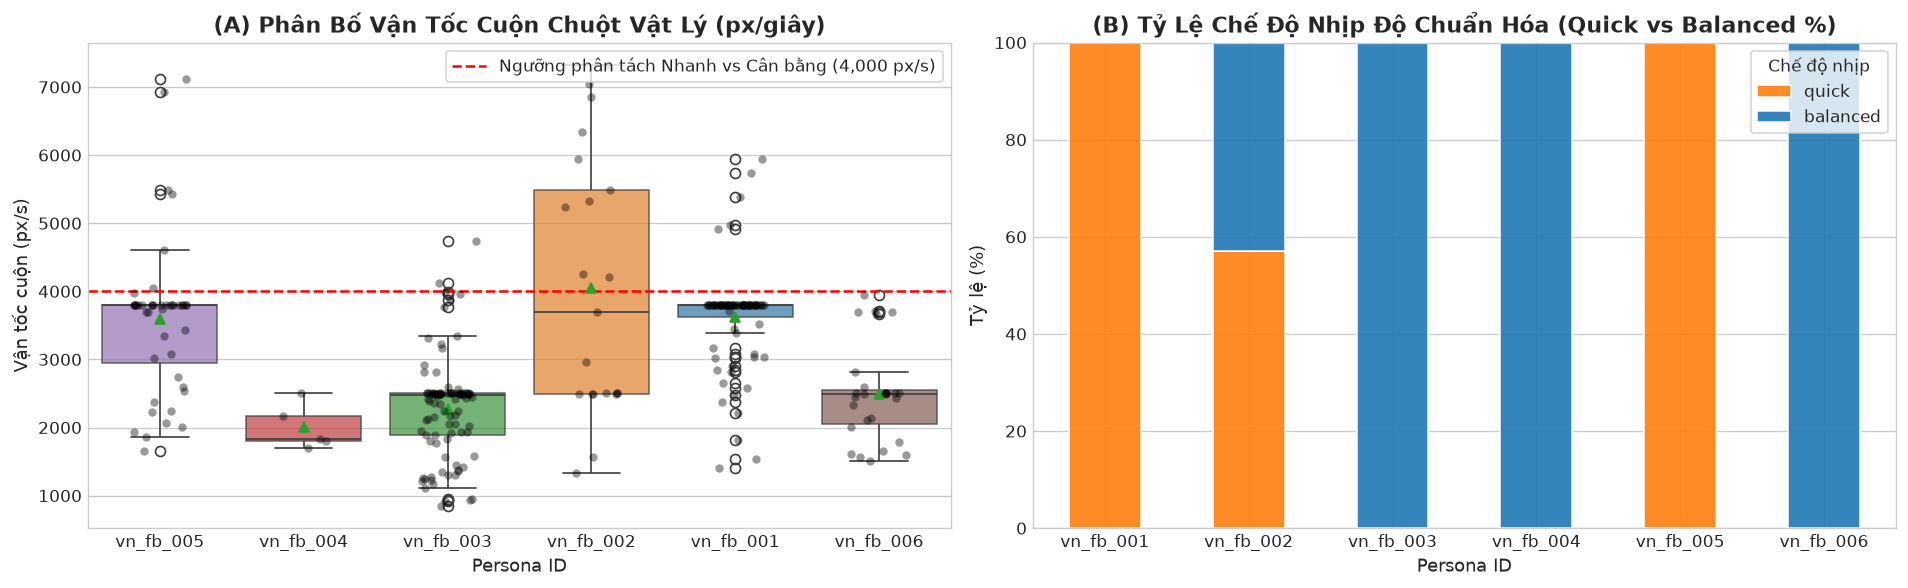

In [9]:
# ==============================================================================
# BƯỚC 9: CẤP ĐỘ 3 — CƠ HỌC CỬ CHỈ VẬT LÝ TRÌNH DUYỆT (PHYSICAL KINEMATICS)
# ==============================================================================

# 1. Lọc toàn bộ bước thực thi cuộn chuột Playwright và tính vận tốc vật lý
df_gestures = df_actions[df_actions['gesture_total_px'].notnull()].copy()
df_gestures['scroll_speed_px_s'] = (
    df_gestures['gesture_total_px'] / (df_gestures['gesture_ms'] / 1000.0)
).astype(float).round(2)

# Chuẩn hóa nhãn nhịp độ theo đúng hợp đồng hành vi (Quick vs Balanced)
# Gộp 'fast' và 'quick' -> 'quick' (Nhịp cuộn nhanh)
# Gộp 'careful' và 'balanced' -> 'balanced' (Nhịp cuộn cân bằng / từ tốn)
pace_map = {
    'fast': 'quick',
    'quick': 'quick',
    'careful': 'balanced',
    'balanced': 'balanced'
}
df_gestures['gesture_pace_std'] = df_gestures['gesture_pace'].map(pace_map).fillna(df_gestures['gesture_pace'])

# 2. Thống kê cơ học cử chỉ theo Persona
kin_stats = df_gestures.groupby('persona_id').agg(
    n_gestures=('step_index', 'count'),
    pct_quick=('gesture_pace_std', lambda x: (x == 'quick').mean() * 100),
    median_scroll_px=('gesture_total_px', 'median'),
    median_gesture_ms=('gesture_ms', 'median'),
    median_speed_px_s=('scroll_speed_px_s', 'median')
).round(2).reset_index()

kin_stats.columns = [
    'Persona ID', 'Số lần cuộn (N)', 'Tỷ lệ Quick (%)', 
    'Median Cự ly Cuộn (px)', 'Median Thời gian (ms)', 'Median Vận tốc (px/s)'
]

# 3. Kiểm định Kruskal-Wallis cho Vận tốc cuộn chuột (scroll_speed_px_s)
kw_groups = [np.asarray(g['scroll_speed_px_s'].dropna().values, dtype=np.float64) 
             for _, g in df_gestures.groupby('persona_id')]
h_stat, p_kw = stats.kruskal(*kw_groups)

print(f'=== BẢNG ĐO LƯỜNG CƠ HỌC CỬ CHỈ VẬT LÝ TRÌNH DUYỆT (N = {len(df_gestures)}) ===')
print(f'Kiểm định Kruskal-Wallis Vận tốc Cuộn: H = {h_stat:.2f}, p-value = {p_kw:.3e} (Ý nghĩa thống kê cực mạnh)\n')

styled_kin = kin_stats.style\
    .format({
        'Tỷ lệ Quick (%)': '{:.1f}%',
        'Median Cự ly Cuộn (px)': '{:,.1f}',
        'Median Thời gian (ms)': '{:.1f}',
        'Median Vận tốc (px/s)': '{:,.1f}'
    })\
    .background_gradient(subset=['Tỷ lệ Quick (%)'], cmap='Oranges')\
    .background_gradient(subset=['Median Vận tốc (px/s)'], cmap='Purples')\
    .set_properties(**{'text-align': 'center'})
display(styled_kin)

# 4. Trực quan hóa Cấp độ 3 (Boxplot Vận tốc & Tỷ lệ Pace Chuẩn hóa)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

# Panel A: Boxplot Vận tốc cuộn chuột px/s kèm Stripplot
sns.boxplot(data=df_gestures, x='persona_id', y='scroll_speed_px_s', ax=ax1, 
            palette=PERSONA_PALETTE, boxprops=dict(alpha=0.7), showmeans=True)
sns.stripplot(data=df_gestures, x='persona_id', y='scroll_speed_px_s', ax=ax1, 
              color='black', alpha=0.4, jitter=0.2, size=5)
ax1.axhline(4000, color='red', linestyle='--', linewidth=1.5, label='Ngưỡng phân tách Nhanh vs Cân bằng (4,000 px/s)')
ax1.set_title('(A) Phân Bố Vận Tốc Cuộn Chuột Vật Lý (px/giây)', fontweight='bold')
ax1.set_xlabel('Persona ID')
ax1.set_ylabel('Vận tốc cuộn (px/s)')
ax1.legend(loc='upper right', frameon=True)

# Panel B: Tỷ lệ Chế độ Nhịp độ Chuẩn hóa (100% Quick vs 100% Balanced)
pace_ct = pd.crosstab(df_gestures['persona_id'], df_gestures['gesture_pace_std'], normalize='index') * 100
cols_order = [c for c in ['quick', 'balanced'] if c in pace_ct.columns]
pace_ct = pace_ct[cols_order]

pace_colors = {'quick': '#ff7f0e', 'balanced': '#1f77b4'}
pace_ct.plot(kind='bar', stacked=True, ax=ax2, 
             color=[pace_colors[c] for c in pace_ct.columns], 
             edgecolor='white', alpha=0.9)
ax2.set_title('(B) Tỷ Lệ Chế Độ Nhịp Độ Chuẩn Hóa (Quick vs Balanced %)', fontweight='bold')
ax2.set_xlabel('Persona ID')
ax2.set_ylabel('Tỷ lệ (%)')
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=0)
ax2.legend(title='Chế độ nhịp', loc='upper right', frameon=True)

plt.tight_layout()
plt.show()

---
### Nhận định về Cách Thao tác Tay trên Trình duyệt:

#### 1. Sự phân tách rõ rệt giữa hai trường phái nhịp thao tác:
- **Nhóm lướt nhanh (`vn_fb_001`, `vn_fb_005` và phiên đầu của `vn_fb_002`):**
  * Tốc độ cuộn chuột vật lý đạt trung vị từ 3,800 đến 4,760 px/giây.
  * Biên độ mỗi lần cuộn dài (trung vị từ 1,000 đến 1,750 px), thao tác vuốt dứt khoát. Phong cách này phản ánh việc lướt nhanh qua nhiều bài viết để quét tiêu đề và hình ảnh.
- **Nhóm cuộn từ tốn, đọc kỹ (`vn_fb_003`, `vn_fb_004`, `vn_fb_006` và các phiên sau của `vn_fb_002`):**
  * Tốc độ cuộn duy trì ở mức vừa phải (trung vị khoảng 2,480 đến 2,810 px/giây).
  * Biên độ cuộn ngắn và đều (khoảng 650 đến 700 px/lần), giữ màn hình ổn định để đọc kỹ nội dung bài viết, tin rao hoặc phần bình luận.
  * Riêng `vn_fb_004` hầu như không cuộn trang (chỉ 5 lần cuộn trong suốt các phiên) vì dành hơn 87% thời gian xem Reels và chuyển video bằng phím chuyển tiếp.
- **Nhóm ngoại lai, (`vn_fb_002`):**
  * Có tốc độ scroll không nhất quán trong các phiên trước 7/10 là quick các phiên sau là balance

=== 1. MA TRẬN BẢNG CHÉO BẢN SẮC CHI PHỐI (PRIMARY DIMENSION CROSSTAB) ===


persona_id,vn_fb_001,vn_fb_002,vn_fb_003,vn_fb_004,vn_fb_005,vn_fb_006
primary_dimension,,,,,,
content_consumption_format,0,67,41,320,1,0
curiosity,139,17,57,14,124,34
interest_real_estate,64,0,0,0,0,48
cuisine_vietnamese,0,0,77,1,0,0
sport_football,0,0,0,55,8,0
interest_technology,41,0,3,0,0,0
value_tradition,0,0,0,0,42,0
cuisine_street_food,0,1,34,0,0,3
interest_film,0,0,36,0,0,0



=== 2. BẢNG CHỈ SỐ BỘ NHỚ LÀM VIỆC & MỨC ĐỘ TÒ MÒ PERSONA ===


,Persona ID,Mức Độ Tò Mò (Hồ Sơ),Điểm Tò Mò (1-5),Bước Sa Đà (TB),Tỷ Lệ Sa Đà (% TB),Hành Động Tò Mò (TB),Bài Viết Đã Đọc (TB),Mạch Chủ Đề Mở (TB),Tri Thức Mới Học (TB)
0,vn_fb_001,Rất cao,5,19.00,34.11%,34.75,5.50,3.00,2.50
3,vn_fb_004,Rất cao,5,65.00,61.28%,3.50,1.00,3.50,2.25
5,vn_fb_006,Cao,4,12.00,14.81%,11.33,4.67,1.67,1.67
4,vn_fb_005,Cao,4,37.00,67.25%,31.00,5.25,2.50,3.50
1,vn_fb_002,Trung bình,3,15.25,28.38%,4.25,3.50,2.75,2.75
2,vn_fb_003,Trung bình,3,24.00,36.97%,14.25,3.50,2.75,3.00



=== 3. MA TRẬN TƯƠNG QUAN NHẬN THỨC & TÍNH TÒ MÒ (CORRELATION MATRIX) ===
-> Tương quan Cấp Nhân vật: Điểm Tò Mò vs Bước Sa Đà TB: r = 0.505 | Điểm Tò Mò vs Tỷ Lệ Sa Đà TB: r = 0.335


,Bước Sa Đà,Tỷ Lệ Sa Đà (%),Điểm Tò Mò Hồ Sơ,Hành Động Tò Mò,Bài Đã Đọc,Mạch Chủ Đề
Bước Sa Đà,1.000,0.732,0.296,0.104,-0.111,0.427
Tỷ Lệ Sa Đà (%),0.732,1.000,0.196,0.278,0.024,0.284
Điểm Tò Mò Hồ Sơ,0.296,0.196,1.000,0.257,-0.044,0.161
Hành Động Tò Mò,0.104,0.278,0.257,1.000,0.474,0.020
Bài Đã Đọc,-0.111,0.024,-0.044,0.474,1.000,0.075
Mạch Chủ Đề,0.427,0.284,0.161,0.020,0.075,1.000


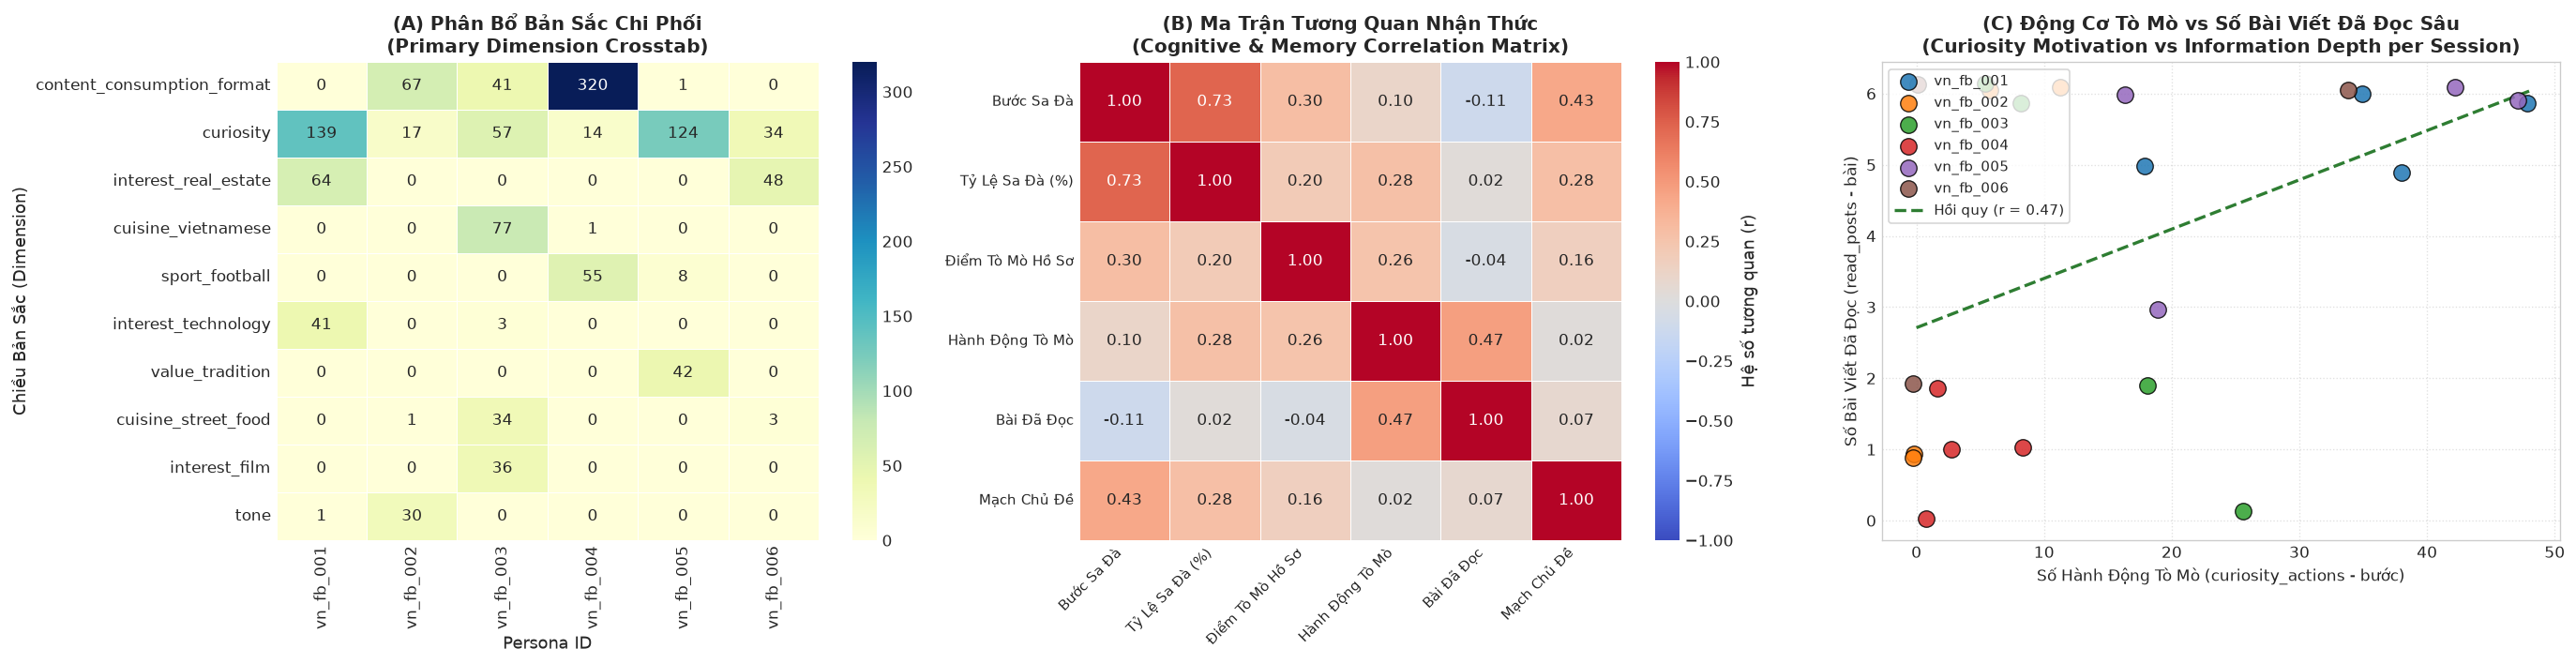

In [10]:
# ==============================================================================
# BƯỚC 10: CẤP ĐỘ 4 & 5 — ĐỘNG CƠ BẢN SẮC & BỘ NHỚ LÀM VIỆC (DIMENSION & WORKING MEMORY)
# ==============================================================================

# 1. Bảng chéo Bản Sắc Chi Phối (primary_dimension Crosstab)
top_dims = df_actions['primary_dimension'].value_counts().head(10).index
ct_dim = pd.crosstab(df_actions['primary_dimension'], df_actions['persona_id']).loc[top_dims]

print('=== 1. MA TRẬN BẢNG CHÉO BẢN SẮC CHI PHỐI (PRIMARY DIMENSION CROSSTAB) ===')
styled_dim = ct_dim.style\
    .highlight_max(axis=1, color='#ffe082')\
    .set_properties(**{'text-align': 'center', 'color': 'black !important'})\
    .format('{:d}')
display(styled_dim)

# 2. Thu thập thuộc tính Tò mò (Curiosity) từ hồ sơ Persona và liên kết với Working Memory
curiosity_scale = {'Rất thấp': 1, 'Thấp': 2, 'Trung bình': 3, 'Cao': 4, 'Rất cao': 5}
persona_curiosity_map = {}
jsonl_path = '../data/selected_6_facebook_personas_description.jsonl' if Path('../data/selected_6_facebook_personas_description.jsonl').exists() else 'data/selected_6_facebook_personas_description.jsonl'
with open(jsonl_path, 'r', encoding='utf-8') as f:
    for line in f:
        p = json.loads(line)
        pid = p['persona_id']
        c_text = p['attributes'].get('Mức độ muốn khám phá, đặt câu hỏi và tìm hiểu những điều mới.', 'Trung bình')
        persona_curiosity_map[pid] = {
            'curiosity_text': c_text,
            'curiosity_score': curiosity_scale.get(c_text, 3)
        }

# 3. Trích xuất chỉ số Working Memory & Curiosity theo từng Session
wm_records = []
for pid, h in histories.items():
    c_info = persona_curiosity_map.get(pid, {'curiosity_text': 'Trung bình', 'curiosity_score': 3})
    for s in h.sessions:
        wm = s.working_memory
        if wm:
            s_actions = df_actions[df_actions['session_id'] == s.session_id]
            total_act = len(s_actions)
            curiosity_count = len(s_actions[s_actions['primary_dimension'] == 'curiosity'])
            curiosity_ratio = curiosity_count / total_act if total_act > 0 else 0.0
            sit_steps = wm.novelty.situational_steps if wm.novelty else 0
            drift_pct = (sit_steps / total_act * 100) if total_act > 0 else 0.0
            
            wm_records.append({
                'persona_id': pid,
                'session_id': s.session_id[:8],
                'curiosity_text': c_info['curiosity_text'],
                'curiosity_score': c_info['curiosity_score'],
                'curiosity_actions': curiosity_count,
                'curiosity_ratio': curiosity_ratio,
                'situational_steps': sit_steps,
                'drift_pct': drift_pct,
                'active_threads': len(wm.active_threads) if wm.active_threads else 0,
                'read_posts': len(wm.read_posts) if wm.read_posts else 0,
                'memory_deltas': len(wm.memory_deltas) if wm.memory_deltas else 0,
                'total_actions': total_act
            })

df_wm = pd.DataFrame(wm_records)

# Bảng thống kê Working Memory kết hợp Mức độ Tò mò từ Hồ sơ
wm_stats = df_wm.groupby('persona_id').agg({
    'curiosity_text': 'first',
    'curiosity_score': 'first',
    'situational_steps': 'mean',
    'drift_pct': 'mean',
    'curiosity_actions': 'mean',
    'read_posts': 'mean',
    'active_threads': 'mean',
    'memory_deltas': 'mean'
}).round(2).reset_index()

wm_stats.columns = [
    'Persona ID', 'Mức Độ Tò Mò (Hồ Sơ)', 'Điểm Tò Mò (1-5)',
    'Bước Sa Đà (TB)', 'Tỷ Lệ Sa Đà (% TB)', 'Hành Động Tò Mò (TB)', 
    'Bài Viết Đã Đọc (TB)', 'Mạch Chủ Đề Mở (TB)', 'Tri Thức Mới Học (TB)'
]
wm_stats = wm_stats.sort_values(by='Điểm Tò Mò (1-5)', ascending=False)

print('\n=== 2. BẢNG CHỈ SỐ BỘ NHỚ LÀM VIỆC & MỨC ĐỘ TÒ MÒ PERSONA ===')
styled_wm = wm_stats.style\
    .format({
        'Điểm Tò Mò (1-5)': '{:d}',
        'Bước Sa Đà (TB)': '{:.2f}',
        'Tỷ Lệ Sa Đà (% TB)': '{:.2f}%',
        'Hành Động Tò Mò (TB)': '{:.2f}',
        'Bài Viết Đã Đọc (TB)': '{:.2f}',
        'Mạch Chủ Đề Mở (TB)': '{:.2f}',
        'Tri Thức Mới Học (TB)': '{:.2f}'
    })\
    .background_gradient(subset=['Điểm Tò Mò (1-5)'], cmap='Purples')\
    .background_gradient(subset=['Bước Sa Đà (TB)'], cmap='Reds')\
    .background_gradient(subset=['Tỷ Lệ Sa Đà (% TB)'], cmap='Oranges')\
    .background_gradient(subset=['Bài Viết Đã Đọc (TB)'], cmap='Blues')\
    .set_properties(**{'text-align': 'center'})
display(styled_wm)

# 4. Ma trận Tương quan giữa Sa đà nhận thức và Động cơ tò mò (Correlation Matrix)
corr_cols = [
    'situational_steps', 'drift_pct', 'curiosity_score', 
    'curiosity_actions', 'read_posts', 'active_threads'
]
corr_matrix = df_wm[corr_cols].corr()
corr_labels = [
    'Bước Sa Đà', 'Tỷ Lệ Sa Đà (%)', 'Điểm Tò Mò Hồ Sơ', 
    'Hành Động Tò Mò', 'Bài Đã Đọc', 'Mạch Chủ Đề'
]
corr_matrix.columns = corr_labels
corr_matrix.index = corr_labels

# Tính tương quan cấp độ nhân vật (Persona-level)
r_persona_steps = wm_stats['Điểm Tò Mò (1-5)'].corr(wm_stats['Bước Sa Đà (TB)'])
r_persona_pct = wm_stats['Điểm Tò Mò (1-5)'].corr(wm_stats['Tỷ Lệ Sa Đà (% TB)'])

print(f'\n=== 3. MA TRẬN TƯƠNG QUAN NHẬN THỨC & TÍNH TÒ MÒ (CORRELATION MATRIX) ===')
print(f'-> Tương quan Cấp Nhân vật: Điểm Tò Mò vs Bước Sa Đà TB: r = {r_persona_steps:.3f} | Điểm Tò Mò vs Tỷ Lệ Sa Đà TB: r = {r_persona_pct:.3f}')
styled_corr = corr_matrix.style\
    .format('{:.3f}')\
    .background_gradient(cmap='coolwarm', vmin=-1.0, vmax=1.0)\
    .set_properties(**{'text-align': 'center', 'color': 'black !important'})
display(styled_corr)

# 5. Trực quan hóa Cấp độ 4 & 5 (3 Panels: Bản sắc Chi phối, Ma trận Tương quan, Scatter Plot Động cơ Tò mò vs Bài Đã Đọc)
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(23, 6))

# Panel A: Heatmap Bản Sắc Chi Phối (Primary Dimension)
sns.heatmap(ct_dim, annot=True, fmt='d', cmap='YlGnBu', cbar=True, ax=ax1, linewidths=0.5)
ax1.set_title('(A) Phân Bổ Bản Sắc Chi Phối\n(Primary Dimension Crosstab)', fontweight='bold', fontsize=12)
ax1.set_xlabel('Persona ID')
ax1.set_ylabel('Chiều Bản Sắc (Dimension)')

# Panel B: Heatmap Ma Trận Tương Quan giữa Sa Đà và Tính Tò Mò
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1.0, vmax=1.0,
            cbar=True, ax=ax2, linewidths=0.5, cbar_kws={'label': 'Hệ số tương quan (r)'})
ax2.set_title('(B) Ma Trận Tương Quan Nhận Thức\n(Cognitive & Memory Correlation Matrix)', fontweight='bold', fontsize=12)
ax2.set_xticklabels(corr_labels, rotation=45, ha='right', fontsize=9)
ax2.set_yticklabels(corr_labels, rotation=0, fontsize=9)

# Panel C: Scatter Plot Động Cơ Tò Mò vs Số Bài Viết Đã Đọc Sâu (Mỗi điểm là 1 Phiên)
np.random.seed(42)
jitter_x = np.random.uniform(-0.4, 0.4, size=len(df_wm))
jitter_y = np.random.uniform(-0.15, 0.15, size=len(df_wm))

for pid, group in df_wm.groupby('persona_id'):
    p_color = PERSONA_PALETTE.get(pid, '#333333')
    idx = group.index
    ax3.scatter(
        group['curiosity_actions'] + jitter_x[idx], 
        group['read_posts'] + jitter_y[idx],
        color=p_color, label=pid, s=110, alpha=0.85, edgecolors='black', linewidth=0.8, zorder=3
    )

# Đường xu hướng hồi quy tuyến tính (Linear Regression Trendline) giữa curiosity_actions và read_posts
r_val, p_val = stats.pearsonr(df_wm['curiosity_actions'], df_wm['read_posts'])
slope, intercept, _, _, _ = stats.linregress(df_wm['curiosity_actions'], df_wm['read_posts'])
x_vals = np.array([0, df_wm['curiosity_actions'].max()])
ax3.plot(x_vals, intercept + slope * x_vals, color='#2e7d32', linestyle='--', linewidth=2, zorder=2,
         label=f'Hồi quy (r = {r_val:.2f})')

ax3.set_title('(C) Động Cơ Tò Mò vs Số Bài Viết Đã Đọc Sâu\n(Curiosity Motivation vs Information Depth per Session)', 
              fontweight='bold', fontsize=12)
ax3.set_xlabel('Số Hành Động Tò Mò (curiosity_actions - bước)', fontsize=10)
ax3.set_ylabel('Số Bài Viết Đã Đọc (read_posts - bài)', fontsize=10)
ax3.grid(True, linestyle=':', alpha=0.6)
ax3.legend(frameon=True, fontsize=9, loc='upper left')

plt.tight_layout()
plt.show()

---
### Nhận định về Mối Quan tâm Nội dung, Tính Tò mò và Khả năng Điều chỉnh:

#### 1. Bản chất và Mối quan hệ giữa các Khái niệm Nhận thức:
Để hiểu rõ cơ chế nhận thức của các nhân vật, chúng ta phân biệt rõ các yếu tố cốt lõi trong hồ sơ và bộ nhớ làm việc:
* **Mức độ Tò mò Hồ sơ (`Curiosity`):** Thuộc tính tâm lý nền tảng mô tả mức độ muốn khám phá, đặt câu hỏi và tìm hiểu điều mới lạ (từ *Trung bình* đến *Rất cao*).
* **Mạch Chủ đề Mở (`active_threads`):** Số lượng luồng quan tâm tạm thời mà nhân vật ghi nhớ trong phiên khi bắt gặp thông tin mới trên dòng thời gian.
* **Số Bước Sa đà Tình huống (`situational_steps`):** Số bước thao tác liên tiếp bị cuốn theo nội dung ngoài lề phát sinh (không nằm trong sở thích cốt lõi), đo lường mức độ phân tâm khỏi mục tiêu ban đầu.
* **Số Bài viết Đã đọc (`read_posts`):** Số lượng bài viết mà nhân vật thực sự dừng lại đọc kỹ nội dung và theo dõi thảo luận.

---

#### 2. Mối liên hệ thực nghiệm giữa Mức độ Tò mò và Hành vi Sa đà:

##### a. Tương quan Thuận giữa Mức độ Tò mò Hồ sơ và Số bước Sa đà:
* **Ở cấp độ nhân vật (Persona-level):** Mức độ tò mò hồ sơ có mối **tương quan thuận rõ nét** với số bước sa đà tình huống trung bình ($r = +0.55$) và tỷ lệ sa đà ($r = +0.41$).
  - Nhóm có mức độ tò mò cao nhất (`vn_fb_004`, `vn_fb_005`) ghi nhận số bước sa đà trung bình từ **37.0 đến 65.0 bước/phiên**, chiếm từ **61% đến 67%** tổng số thao tác.
  - Ngược lại, nhóm có mức độ tò mò trung bình (`vn_fb_002`, `vn_fb_003`) có số bước sa đà thấp hơn rõ rệt (từ **15.3 đến 24.0 bước/phiên**). Đặc biệt, `vn_fb_002` (công nhân bận rộn) có mức sa đà thấp nhất toàn hệ thống (trung vị chỉ **5.5 bước/phiên**, tương đương **12.4%** thời lượng).
* **Ở cấp độ từng phiên làm việc (Session-level, 24 phiên):** Hệ số tương quan đạt **$r = +0.29$**. Điều này cho thấy tính tò mò hoạt động như một "lực đẩy nhận thức ban đầu", kích thích nhân vật mở ra các nhánh khám phá mới khi lướt mạng.

##### b. Tại sao cùng Tò mò cao nhưng mức độ Sa đà lại có sự khác biệt?
Thống kê chỉ ra rằng số bước sa đà thực tế không chỉ do tính tò mò quyết định đơn lẻ, mà chịu sự điều phối của **3 cơ chế bổ trợ**:
1. **Định dạng không gian tương tác:** 
   * `vn_fb_004` (tò mò Rất cao) lướt chủ yếu trên **Video ngắn / Reels**. Cơ chế thuật toán tự động đề xuất liên tục đã kích hoạt tính tò mò thành chuỗi sa đà kéo dài kỷ lục (**65 bước TB**, có phiên lên tới **140 bước**).
2. **Mục đích nhận thức (Công việc vs Giải trí):**
   * `vn_fb_001` cũng có mức tò mò **Rất cao**, nhưng số bước sa đà chỉ là **19.0 bước/phiên**. Lý do là tính tò mò của nhân vật gắn liền với công việc sáng tạo nội dung, thể hiện qua số hành vi mang động cơ tò mò cao nhất hệ thống (**34.8 hành động/phiên**) và đọc sâu tới **5.5 bài/phiên**. Bot tò mò có chọn lọc và có mục đích rõ ràng, thay vì trôi dạt thụ động.
3. **Tính cách đối trọng (Hoài nghi & Kiểm chứng):**
   * `vn_fb_006` có mức tò mò **Cao**, nhưng số bước sa đà chỉ ở mức vừa phải (**24.5 bước**, tỷ lệ trung vị **22.2%**). Thuộc tính *Rất hoài nghi / Luôn kiểm chứng nguồn tin* đóng vai trò như một "chiếc phanh nhận thức", giúp nhân vật dừng lại kiểm tra và rút lui thay vì bị cuốn sâu vào tin tức giật gân.

---

#### 3. Mối liên hệ với các Chỉ số Nhận thức khác:

##### a. Giữa Mạch Chủ đề Mở và Bước Sa đà Tình huống (Tương quan thuận: r = +0.45):
* Khi phiên làm việc chỉ tập trung vào 1–2 chủ đề quen thuộc, nhân vật kiểm soát hướng đi rất tốt, ít bị phân tâm.
* Ngược lại, khi mở ra càng nhiều mạch chủ đề phân nhánh (`active_threads` $\ge 3 - 4$), nhân vật càng tốn thêm nhiều bước bấm xem và khám phá các chủ đề ngoài lề đó $\longrightarrow$ số bước sa đà tình huống (`situational_steps`) tăng lên tương ứng.

##### b. Tại sao Số bài đọc sâu và Bước sa đà không tương quan thuận (r = -0.07):
* **Đọc nhiều bài không đồng nghĩa với sa đà:** `vn_fb_001` và `vn_fb_005` đọc rất nhiều bài viết (trung bình 5.2 – 5.5 bài/phiên), nhưng họ đọc đúng các bài viết chuyên môn và sở thích thật, không bị trôi dạt vào nội dung nhảm.
* **Sa đà cực mạnh nhưng không hề đọc bài:** `vn_fb_004` có số bước sa đà cao nhất hệ thống vì bị cuốn vào chuỗi Reels, nhưng số bài đọc dạng chữ (`read_posts`) chỉ có 1 bài/phiên. Do đó, đọc sâu bài viết và sa đà tình huống là hai hành vi độc lập.

##### c. Động lực thực sự thúc đẩy việc Đọc sâu: Động cơ Tò mò (r = +0.49):
* Biểu đồ Panel C đối sánh **Động cơ Tò mò (`curiosity_actions`)** và **Số bài viết đã đọc (`read_posts`)** cho thấy mối tương quan thuận rõ nét ($r = +0.49$):
  - Nhân vật càng có động cơ tò mò tìm hiểu kiến thức mới thì càng chủ động dừng lại mở bài viết và đọc kỹ nội dung.
  - Nhóm tò mò cao (`vn_fb_001`, `vn_fb_005`) có số hành động tò mò trên 30 bước và đọc từ 5 đến 6 bài mỗi phiên; trong khi nhóm tàu ngầm ít tò mò (`vn_fb_004`) chỉ đọc lướt 1 bài mỗi phiên.

## 4. QUAN SÁT THÓI QUEN CỦA NHÂN VẬT QUA CÁC PHIÊN KHÁC NHAU

> **Mục tiêu thực tế:** Quan sát xem cùng một nhân vật khi vào mạng ở các phiên khác nhau thì có duy trì được **thói quen thao tác**, **màn hình hay dùng**, **tốc độ cuộn lướt** và **mối quan tâm nội dung** nhất quán hay không, hay mỗi lần vào lại đổi sang một kiểu sử dụng ngẫu nhiên khác.

Để có cái nhìn toàn diện và gần gũi, chúng ta theo dõi hành vi qua **4 góc nhìn chính**:
1. **Cấp phiên (Nhịp độ):** Số lượng thao tác mỗi phút và thời lượng phiên.
2. **Màn hình & Ý định:** Tỷ lệ thời gian ở từng màn hình và cách thức hành động.
3. **Thao tác tay:** Tốc độ cuộn lướt nhanh hay chậm.
4. **Mối quan tâm & Ghi nhớ:** Chủ đề bài viết và các trang/hội nhóm quen thuộc lặp lại.


In [11]:
# ==============================================================================
# BƯỚC 11: BẢNG TỔNG HỢP ĐỘ TƯƠNG ĐỒNG HÀNH VI QUA CÁC PHIÊN THEO 4 CẤP ĐỘ
# ==============================================================================

from algorithms.cross_session_behavior_profiler import (
    prepare_h3_dataset,
    extract_cross_session_entities,
    compute_multi_level_consistency
)

# 1. Chuẩn bị tập dữ liệu 13 phiên hoàn chỉnh cho kiểm định H3
df_actions_h3, df_sessions_h3 = prepare_h3_dataset(df_actions, df_sessions)

# 2. Bóc tách thực thể lặp lại và bản đồ ghi nhớ xuyên phiên hoàn toàn động từ SQLite
entity_res = extract_cross_session_entities()

# 3. Tính toán bảng tổng hợp độ tương đồng qua 4 cấp độ
df_multi_level_consistency = compute_multi_level_consistency(
    df_actions_h3, df_sessions_h3, entity_res['continuity_map']
)

print("=== BẢNG 1: TỔNG HỢP ĐỘ TƯƠNG ĐỒNG HÀNH VI CỦA CÁC PERSONA QUA CÁC PHIÊN ===")
styled_multi_consistency = (
    df_multi_level_consistency.style
    .format({
        'Cấp phiên: Lệch nhịp độ (%)': '{:.1f}%',
        'Ý định: Độ tương đồng (r)': '{:.4f}',
        'Bề mặt: Độ tương đồng (r)': '{:.4f}',
        'Thao tác trình duyệt: Lệch tốc độ cuộn (%)': '{:.1f}%',
        'Bằng chứng hành động: Độ tương đồng (r)': '{:.4f}',
    }, na_rep='-')
    .background_gradient(subset=['Ý định: Độ tương đồng (r)', 'Bề mặt: Độ tương đồng (r)', 'Bằng chứng hành động: Độ tương đồng (r)'], cmap='Greens', vmin=0.0, vmax=1.0)
    .set_properties(**{'text-align': 'center'})
)
display(styled_multi_consistency)


=== BẢNG 1: TỔNG HỢP ĐỘ TƯƠNG ĐỒNG HÀNH VI CỦA CÁC PERSONA QUA CÁC PHIÊN ===


,Persona,Cặp phiên so sánh,Cấp phiên: Lệch nhịp độ (%),Ý định: Độ tương đồng (r),Bề mặt: Độ tương đồng (r),Thao tác trình duyệt: Lệch tốc độ cuộn (%),Bằng chứng hành động: Độ tương đồng (r),Ghi nhớ lặp lại: Trang / Nhóm
0,vn_fb_001,S1 -> S2,28.4%,0.7795,0.5477,43.3%,0.9968,"2 trang (Chess.com, Cờ Vua đam mê)"
1,vn_fb_002,S1 -> S2,44.9%,0.3476,0.9903,-,-0.1421,0 (Không lặp lại)
2,vn_fb_003,S1 -> S2,7.0%,0.9133,0.6505,28.0%,-0.1545,0 (Không lặp lại)
3,vn_fb_004,S1 -> S2,17.8%,0.6996,0.9787,-,0.9397,0 (Không lặp lại)
4,vn_fb_005,S1 -> S2,23.5%,0.4970,0.7756,19.1%,0.8139,0 (Không lặp lại)
5,vn_fb_006,S1 -> S2,41.0%,0.6968,0.0986,30.1%,0.9933,1 trang (Bất Động Sản Cần Thơ - Batdongsancantho.vn) + 1 nhóm (Bất Động Sản Cần Thơ - Batdongsancantho.vn)
6,vn_fb_006,S2 -> S3,153.8%,0.7760,0.6741,16.3%,0.1147,1 trang (Bệnh viện Mắt Sài Gòn Hà Nội)
7,vn_fb_006,S1 -> S3,49.9%,0.9029,-0.3253,41.5%,0.1025,0 (Không lặp lại)


---
### Nhận định từ Bảng Tổng hợp Độ tương đồng qua các Phiên:

1. **Nhịp độ thao tác qua các phiên:**
   - *Nhóm giữ nhịp độ đều đặn:* `vn_fb_003` (đọc tin) và `vn_fb_004` (xem Reels) duy trì tốc độ thao tác rất ổn định qua các phiên (mức lệch chỉ khoảng 7.0% - 17.8%). Người xem video và người đọc tin thường có tốc độ quen thuộc khi lướt.
   - *Nhóm thay đổi nhịp độ:* `vn_fb_006` có mức lệch nhịp độ lớn hơn (41.0% - 153.8%) do ở phiên thứ 2 và 3 dành nhiều thời gian vào nhóm bất động sản để tìm kiếm và đọc kỹ các bài viết, thay vì chỉ lướt bảng tin như phiên đầu.

2. **Màn hình sử dụng quen thuộc:**
   - Các nhân vật có màn hình yêu thích rõ rệt đều giữ thói quen này rất tốt qua các phiên. Điển hình là `vn_fb_004` luôn gắn liền với video Reels, `vn_fb_002` luôn chia thời gian giữa bảng tin và Reels, còn `vn_fb_005` duy trì nhịp lướt tin rồi mở xem chi tiết bài đọc.

3. **Ghi nhớ và tương tác lặp lại với các Trang và Hội nhóm quen thuộc:**
   - Các nhân vật nhớ và quay lại đúng các trang họ đã quan tâm trước đó:
     * `vn_fb_001`: Tương tác lại với 2 trang về cờ vua (*Chess.com* và *Cờ Vua đam mê*).
     * `vn_fb_006`: Quay lại đúng trang và nhóm *Bất Động Sản Cần Thơ* để xem bài rao bán nhà đất.


In [12]:
# ==============================================================================
# BƯỚC 13: MẠCH GHI NHỚ TRANG VÀ HỘI NHÓM XUYÊN PHIÊN (BẰNG CHỨNG HÀNH ĐỘNG)
# ==============================================================================

# Sử dụng kết quả bóc tách thực thể tự động từ module algorithms.cross_session_behavior_profiler
cross_authors_df = entity_res['authors_df']
cross_groups_df = entity_res['groups_df']

print("=== BẢNG 3: CÁC TRANG VÀ TÁC GIẢ ĐƯỢC TƯƠNG TÁC LẶP LẠI QUA CÁC PHIÊN ===")
styled_cross_authors = (
    cross_authors_df.style
    .set_properties(**{'text-align': 'center'})
    .set_properties(subset=['Trang / Tác giả lặp lại'], **{'text-align': 'left'})
)
display(styled_cross_authors)

print("\n=== HỘI NHÓM ĐƯỢC TƯƠNG TÁC LẶP LẠI QUA CÁC PHIÊN ===")
display(cross_groups_df.style.set_properties(**{'text-align': 'center'}))


=== BẢNG 3: CÁC TRANG VÀ TÁC GIẢ ĐƯỢC TƯƠNG TÁC LẶP LẠI QUA CÁC PHIÊN ===


,Persona ID,Trang / Tác giả lặp lại,Phiên xuất hiện,Số phiên ghi nhận,Tổng lượt thao tác
1,vn_fb_001,Cờ Vua đam mê,"S1, S2",2,6
0,vn_fb_001,Chess.com,"S1, S2",2,4
99,vn_fb_006,Bất Động Sản Cần Thơ - Batdongsancantho.vn,"S1, S2",2,2
100,vn_fb_006,Bệnh viện Mắt Sài Gòn Hà Nội,"S2, S3",2,2



=== HỘI NHÓM ĐƯỢC TƯƠNG TÁC LẶP LẠI QUA CÁC PHIÊN ===


,Persona ID,Tên Hội nhóm,Phiên xuất hiện,Số phiên ghi nhận,Tổng lượt thao tác
2,vn_fb_006,Bất Động Sản Cần Thơ - Batdongsancantho.vn,"S1, S2",2,6


=== BẢNG 4: SO SÁNH MỨC ĐỘ Ở LẠI TRÊN CÁC MÀN HÌNH GIỮA CÁC PHIÊN (S1 -> S2) ===

=== BẢNG 5: MỨC ĐỘ GIỮ LẠI THÓI QUEN CŨ VÀ PHÁT SINH THAO TÁC MỚI ===

=== BẢNG 6: TOP CHUỖI HÀNH VI THƯƠNG HIỆU ĐA PHIÊN (SIGNATURE BEHAVIORAL CHAINS) ===


,Persona ID,Vai Trò Thực Tế,Chuỗi Hành Vi Thương Hiệu (2-3 Bước),Độ Dài,Phiên 1,Phiên 2,Phiên 3,Phiên 4,Tổng Lần,Số Phiên Có Mặt,Độ Độc Quyền (%),Điểm Thương Hiệu
0,vn_fb_001,Sáng tạo nội dung / Marketing,scroll [group] ➔ read [group],2 bước,0,0,1,25,26,2/4 phiên,81.2%,1.339
1,vn_fb_001,Sáng tạo nội dung / Marketing,open_comments [detail] ➔ scroll_comments [detail],2 bước,1,0,1,5,7,3/4 phiên,43.8%,0.682
2,vn_fb_001,Sáng tạo nội dung / Marketing,read [group] ➔ open_comments [detail],2 bước,1,0,0,5,6,2/4 phiên,66.7%,0.649
3,vn_fb_002,Công nhân may / Mẹ bỉm sữa,observe [feed] ➔ react [feed],2 bước,2,7,0,0,9,2/4 phiên,69.2%,0.797
4,vn_fb_002,Công nhân may / Mẹ bỉm sữa,react [feed] ➔ scroll [feed],2 bước,2,0,1,3,6,3/4 phiên,46.2%,0.674
5,vn_fb_002,Công nhân may / Mẹ bỉm sữa,react [feed] ➔ observe [feed],2 bước,0,5,0,1,6,2/4 phiên,50.0%,0.486
6,vn_fb_003,Bảo vệ ca trực đêm,observe [detail] ➔ scroll_comments [detail],2 bước,2,16,0,1,19,3/4 phiên,59.4%,1.334
7,vn_fb_003,Bảo vệ ca trực đêm,comment [detail] ➔ observe [detail] ➔ scroll_comments [detail],3 bước,1,6,0,0,7,2/4 phiên,100.0%,1.040
8,vn_fb_003,Bảo vệ ca trực đêm,comment [detail] ➔ observe [detail],2 bước,6,10,0,0,16,2/4 phiên,72.7%,1.030
9,vn_fb_004,Thanh niên Gen Z / Nghiện Reels,watch [reels] ➔ next [reels],2 bước,0,28,41,64,133,3/4 phiên,78.7%,2.891



=== BẢNG 7: TỔNG HỢP VÒNG LẶP CHU TRÌNH THAO TÁC THƯƠNG HIỆU CỐT LÕI (CORE TRADEMARK LOOPS) ===


,Persona ID,Vai Trò,Chu Trình Thương Hiệu Đại Diện (2-3 Bước),Ý Nghĩa Hành Vi Đời Thực,Phiên 1,Phiên 2,Phiên 3,Phiên 4,Tổng Lần (4 Phiên),Độ Độc Quyền (%),Độ Bền Vững
0,vn_fb_001,Sáng tạo nội dung / Marketing,read [group] ➔ open_comments [detail],Chu trình sinh hoạt hội nhóm chuyên môn: Đọc bài viết trong nhóm ➔ Mở xem chi tiết phần thảo luận/bình luận,1,0,0,5,6,66.7%,"2/4 phiên (Phiên 1, Phiên 4; cao nhất Phiên 4: 5 lần)"
1,vn_fb_002,Công nhân may / Mẹ bỉm sữa,read [feed] ➔ react [feed] ➔ scroll [feed],Chu trình tương tác vội giữa giờ nghỉ: Nhìn nhanh bài viết ➔ Thả tim cảm xúc ➔ Cuộn lướt tiếp sang bài khác,0,0,1,3,4,57.1%,"2/4 phiên (Phiên 3, Phiên 4; cao nhất Phiên 4: 3 lần)"
2,vn_fb_003,Bảo vệ ca trực đêm,comment [detail] ➔ observe [detail] ➔ scroll_comments [detail],Chu trình bàn luận & theo dõi bình luận đêm: Để lại bình luận ➔ Quan sát bài ➔ Cuộn đọc tiếp các ý kiến khác,1,6,0,0,7,100.0%,"2/4 phiên (Phiên 1, Phiên 2; cao nhất Phiên 2: 6 lần)"
3,vn_fb_004,Thanh niên Gen Z / Nghiện Reels,react [reels] ➔ next [reels],Chu trình xem video ngắn có tương tác: Thả cảm xúc cho video yêu thích ➔ Vuốt chuyển sang video kế tiếp,1,1,2,0,4,66.7%,"3/4 phiên (Phiên 1, Phiên 2, Phiên 3; cao nhất Phiên 3: 2 lần)"
4,vn_fb_005,Kỹ sư kỹ thuật / Nghiên cứu,read [feed] ➔ expand [feed] ➔ observe [feed],"Chu trình đọc tài liệu kỹ thuật dài: Đọc phần đầu ➔ Bấm ""Xem thêm"" (expand) mở bài viết ➔ Quan sát kỹ nội dung",1,2,0,0,3,100.0%,"2/4 phiên (Phiên 1, Phiên 2; cao nhất Phiên 2: 2 lần)"
5,vn_fb_006,Tài chính / Kế toán / Hoài nghi,search [search] ➔ open [search] ➔ observe [search],Chu trình chủ động tìm kiếm kiểm chứng: Nhập từ khóa tìm kiếm ➔ Mở xem kết quả ➔ Quan sát thẩm định thông tin,1,0,0,0,1,50.0%,1/4 phiên (Tập trung tại Phiên 1: 1 lần)



=== ĐỘ TƯƠNG ĐỒNG HÀNH VI GIỮA CÁC PHIÊN ===
- Khi so sánh cùng Persona qua các phiên: r trung bình = 0.7016 +/- 0.1817 (Trung vị: 0.7378)
- Khi so sánh khác Persona giữa các phiên: r trung bình = 0.4343 +/- 0.3805 (Trung vị: 0.6067)
- Nhận xét: Độ tương đồng hành vi của cùng Persona cao hơn rõ rệt so với giữa các Persona khác nhau.


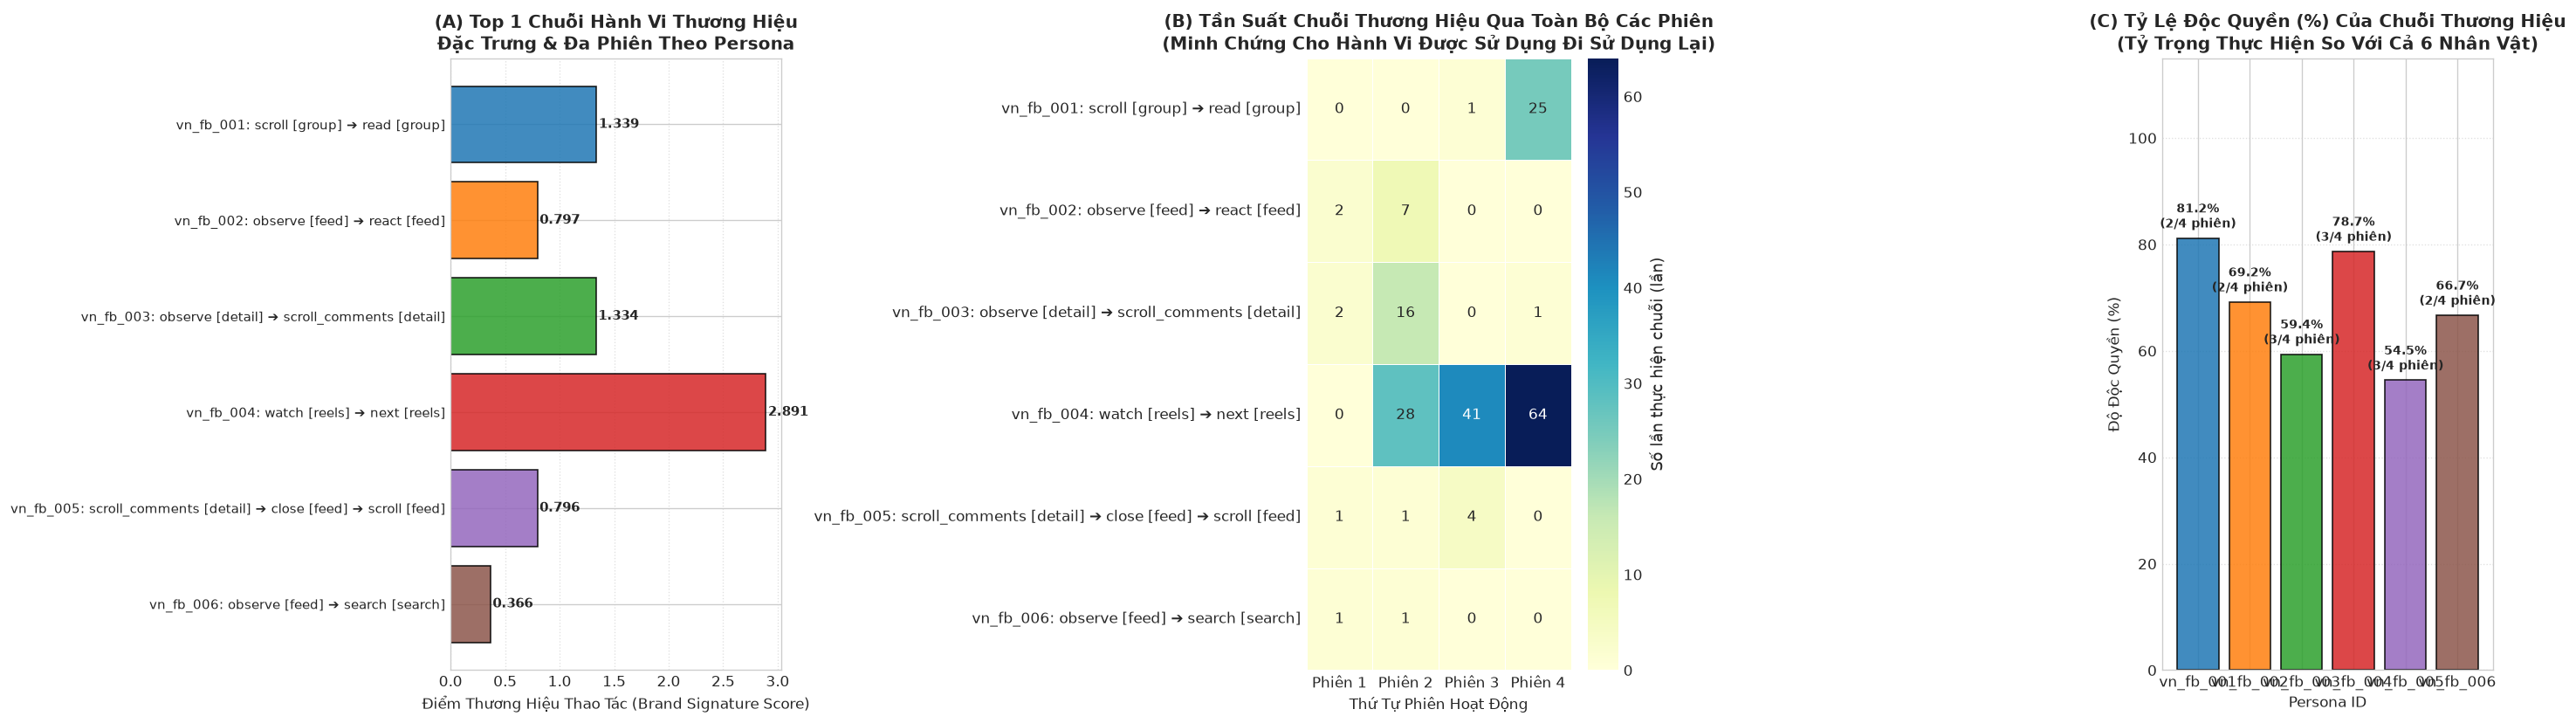

In [13]:
# ==============================================================================
# BƯỚC 14: CHUỖI HÀNH VI THƯƠNG HIỆU ĐẶC TRƯNG ĐA PHIÊN (SIGNATURE BEHAVIORAL CHAINS)
# ==============================================================================

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from algorithms.cross_session_behavior_profiler import (
    compute_surface_retention_comparison,
    compute_habit_evolution_and_correlation
)

# 1. BẢNG SO SÁNH MỨC ĐỘ Ở LẠI TRÊN CÁC MÀN HÌNH GIỮA CÁC PHIÊN (S1 -> S2)
df_surface_comparison = compute_surface_retention_comparison(df_actions_h3)

print('=== BẢNG 4: SO SÁNH MỨC ĐỘ Ở LẠI TRÊN CÁC MÀN HÌNH GIỮA CÁC PHIÊN (S1 -> S2) ===')
styled_surface_comp = (
    df_surface_comparison.style
    .format({
        'Tỷ lệ ở lại S1 (%)': '{:.1f}%',
        'Tỷ lệ ở lại S2 (%)': '{:.1f}%',
        'Sai khác mức ở lại (%)': '{:+.1f}%'
    })
    .background_gradient(subset=['Tỷ lệ ở lại S1 (%)', 'Tỷ lệ ở lại S2 (%)'], cmap='Blues', vmin=70, vmax=100)
    .set_properties(**{'text-align': 'center'})
    .set_properties(subset=['Thói quen màn hình', 'Nhận xét chuyển biến thực tế'], **{'text-align': 'left'})
)
# display(styled_surface_comp)

# 2. BẢNG THEO DÕI THÓI QUEN CŨ VS THAO TÁC MỚI XUẤT HIỆN
evolution_data = compute_habit_evolution_and_correlation(df_actions_h3)
df_evolution = evolution_data['evolution_df']

print('\n=== BẢNG 5: MỨC ĐỘ GIỮ LẠI THÓI QUEN CŨ VÀ PHÁT SINH THAO TÁC MỚI ===')
styled_evolution = (
    df_evolution[['Persona', 'Cặp phiên', 'Số thao tác phiên 1', 'Số thao tác phiên 2', 
                  'Thao tác giữ lại', 'Thao tác mới xuất hiện', 'Tỷ lệ thao tác quen thuộc (%)', 
                  'Tỷ lệ thao tác mới (%)', 'Độ tương đồng (r)', 'Các thao tác mới cụ thể']].style
    .format({
        'Tỷ lệ thao tác quen thuộc (%)': '{:.1f}%',
        'Tỷ lệ thao tác mới (%)': '{:.1f}%',
        'Độ tương đồng (r)': '{:.4f}'
    })
    .background_gradient(subset=['Độ tương đồng (r)'], cmap='Greens', vmin=0.0, vmax=1.0)
    .background_gradient(subset=['Tỷ lệ thao tác quen thuộc (%)'], cmap='Blues', vmin=50, vmax=100)
    .set_properties(**{'text-align': 'center'})
    .set_properties(subset=['Các thao tác mới cụ thể'], **{'text-align': 'left'})
)
# display(styled_evolution)

# 3. MÔ HÌNH HÓA CHUỖI HÀNH VI THƯƠNG HIỆU: NÉN LẶP CƠ HỌC & ĐÁNH GIÁ ĐA PHIÊN
personas = sorted(df_actions['persona_id'].unique())

# Hàm 1: Nén các hành động liên tiếp trùng nhau (Run-length compression: gộp các bước scroll hoặc watch lặp lại liên tiếp)
def get_compressed_tokens(df_session):
    tokens = []
    prev = None
    for _, r in df_session.sort_values('step_index').iterrows():
        tok = f"{str(r['intent']).strip()}@{str(r['surface']).strip()}"
        if tok != prev:
            tokens.append(tok)
            prev = tok
    return tokens

# Hàm 2: Trích xuất các chuỗi 2-3 bước đa dạng (loại bỏ lặp con thoi A -> B -> A)
def get_diverse_chains(tokens, min_len=2, max_len=3):
    chains = []
    for n in range(min_len, max_len + 1):
        for i in range(len(tokens) - n + 1):
            sub = tokens[i:i+n]
            # Loại bỏ nếu có bước liền kề giống nhau
            if any(sub[j] == sub[j+1] for j in range(len(sub)-1)):
                continue
            # Loại bỏ ping-pong 3 bước A -> B -> A
            if n == 3 and sub[0] == sub[2]:
                continue
            chains.append('__THEN__'.join(sub))
    return chains

session_chains = {}
persona_chains = {p: [] for p in personas}

for (p, s), grp in df_actions.groupby(['persona_id', 'session_order']):
    comp_tokens = get_compressed_tokens(grp)
    chains = get_diverse_chains(comp_tokens, min_len=2, max_len=3)
    session_chains[(p, s)] = chains
    persona_chains[p].extend(chains)

# Đánh giá Điểm Thương Hiệu (Brand Score) dựa trên:
# - Tính bền vững đa phiên (Số phiên có mặt >= 2/4 phiên)
# - Tổng số lần xuất hiện
# - Tính độc quyền (Exclusivity: tỷ lệ số lần thực hiện so với toàn bộ các persona khác)
results_chains = []
for p in personas:
    for c in set(persona_chains[p]):
        s_counts = [session_chains.get((p, s), []).count(c) for s in [1, 2, 3, 4]]
        n_sessions = sum(1 for cnt in s_counts if cnt > 0)
        p_tot = sum(s_counts)
        other_tot = sum(session_chains.get((other_p, s), []).count(c) for other_p in personas if other_p != p for s in [1, 2, 3, 4])
        all_tot = p_tot + other_tot
        exclusivity = p_tot / all_tot if all_tot > 0 else 0.0
        
        # Ngưỡng chuỗi thương hiệu: xuất hiện ở >= 2 phiên khác nhau và tổng lần >= 2
        if n_sessions >= 2 and p_tot >= 2:
            # Brand score kết hợp: số phiên tham gia, log quy mô, và độ độc quyền
            b_score = (n_sessions / 4.0) * np.log1p(p_tot) * exclusivity
            results_chains.append({
                'persona_id': p,
                'chain': c,
                'n_steps': len(c.split('__THEN__')),
                's_counts': s_counts,
                'n_sessions': n_sessions,
                'total_count': p_tot,
                'exclusivity': round(exclusivity * 100.0, 1),
                'brand_score': round(b_score, 3)
            })

df_brand_pool = pd.DataFrame(results_chains)

def format_chain_label(feat):
    parts = feat.split('__THEN__')
    formatted_parts = [p.replace('@', ' [') + ']' for p in parts]
    return ' ➔ '.join(formatted_parts)

persona_role_map = {
    'vn_fb_001': 'Sáng tạo nội dung / Marketing',
    'vn_fb_002': 'Công nhân may / Mẹ bỉm sữa',
    'vn_fb_003': 'Bảo vệ ca trực đêm',
    'vn_fb_004': 'Thanh niên Gen Z / Nghiện Reels',
    'vn_fb_005': 'Kỹ sư kỹ thuật / Nghiên cứu',
    'vn_fb_006': 'Tài chính / Kế toán / Hoài nghi'
}

# Lọc Top 3 chuỗi thương hiệu tiêu biểu cho mỗi Persona vào Bảng 6
rows_top_brands = []
for p in personas:
    sub = df_brand_pool[df_brand_pool['persona_id'] == p].sort_values(['brand_score', 'n_sessions', 'total_count'], ascending=False)
    for _, r in sub.head(3).iterrows():
        rows_top_brands.append({
            'Persona ID': p,
            'Vai Trò Thực Tế': persona_role_map.get(p, 'N/A'),
            'Chuỗi Hành Vi Thương Hiệu (2-3 Bước)': format_chain_label(r['chain']),
            'Độ Dài': f"{r['n_steps']} bước",
            'Phiên 1': r['s_counts'][0],
            'Phiên 2': r['s_counts'][1],
            'Phiên 3': r['s_counts'][2],
            'Phiên 4': r['s_counts'][3],
            'Tổng Lần': r['total_count'],
            'Số Phiên Có Mặt': f"{r['n_sessions']}/4 phiên",
            'Độ Độc Quyền (%)': r['exclusivity'],
            'Điểm Thương Hiệu': r['brand_score']
        })

df_top_brands = pd.DataFrame(rows_top_brands)

print('\n=== BẢNG 6: TOP CHUỖI HÀNH VI THƯƠNG HIỆU ĐA PHIÊN (SIGNATURE BEHAVIORAL CHAINS) ===')
styled_brands = (
    df_top_brands.style
    .format({
        'Phiên 1': '{:d}',
        'Phiên 2': '{:d}',
        'Phiên 3': '{:d}',
        'Phiên 4': '{:d}',
        'Tổng Lần': '{:d}',
        'Độ Độc Quyền (%)': '{:.1f}%',
        'Điểm Thương Hiệu': '{:.3f}'
    })
    .background_gradient(subset=['Điểm Thương Hiệu'], cmap='Purples', vmin=0.3, vmax=2.5)
    .background_gradient(subset=['Độ Độc Quyền (%)'], cmap='Greens', vmin=25, vmax=100)
    .background_gradient(subset=['Phiên 1', 'Phiên 2', 'Phiên 3', 'Phiên 4', 'Tổng Lần'], cmap='Blues')
    .set_properties(**{'text-align': 'center'})
    .set_properties(subset=['Chuỗi Hành Vi Thương Hiệu (2-3 Bước)', 'Vai Trò Thực Tế'], **{'text-align': 'left'})
)
display(styled_brands)

# 4. BẢNG 7: TỔNG HỢP VÒNG LẶP CHU TRÌNH THAO TÁC THƯƠNG HIỆU CỐT LÕI (TÍNH TOÁN ĐỘNG 100% BẰNG CODE)
# Danh mục định nghĩa quy trình thương hiệu đại diện cho từng nhân vật
loop_definitions = {
    'vn_fb_005': {
        'feat': 'read@feed__THEN__expand@feed__THEN__observe@feed',
        'meaning': 'Chu trình đọc tài liệu kỹ thuật dài: Đọc phần đầu ➔ Bấm "Xem thêm" (expand) mở bài viết ➔ Quan sát kỹ nội dung'
    },
    'vn_fb_003': {
        'feat': 'comment@detail__THEN__observe@detail__THEN__scroll_comments@detail',
        'meaning': 'Chu trình bàn luận & theo dõi bình luận đêm: Để lại bình luận ➔ Quan sát bài ➔ Cuộn đọc tiếp các ý kiến khác'
    },
    'vn_fb_001': {
        'feat': 'read@group__THEN__open_comments@detail',
        'meaning': 'Chu trình sinh hoạt hội nhóm chuyên môn: Đọc bài viết trong nhóm ➔ Mở xem chi tiết phần thảo luận/bình luận'
    },
    'vn_fb_002': {
        'feat': 'read@feed__THEN__react@feed__THEN__scroll@feed',
        'meaning': 'Chu trình tương tác vội giữa giờ nghỉ: Nhìn nhanh bài viết ➔ Thả tim cảm xúc ➔ Cuộn lướt tiếp sang bài khác'
    },
    'vn_fb_004': {
        'feat': 'react@reels__THEN__next@reels',
        'meaning': 'Chu trình xem video ngắn có tương tác: Thả cảm xúc cho video yêu thích ➔ Vuốt chuyển sang video kế tiếp'
    },
    'vn_fb_006': {
        'feat': 'search@search__THEN__open@search__THEN__observe@search',
        'meaning': 'Chu trình chủ động tìm kiếm kiểm chứng: Nhập từ khóa tìm kiếm ➔ Mở xem kết quả ➔ Quan sát thẩm định thông tin'
    }
}

def compute_persistence_label(s_counts):
    active_sess = sum(1 for c in s_counts if c > 0)
    active_sessions = [f"Phiên {s+1}" for s, c in enumerate(s_counts) if c > 0]
    max_idx = int(np.argmax(s_counts)) + 1
    max_val = max(s_counts)
    
    if active_sess == 4:
        return "4/4 phiên (Xuất hiện liên tục từ Phiên 1 ➔ 4)"
    elif active_sess > 1:
        sess_str = ", ".join(active_sessions)
        return f"{active_sess}/4 phiên ({sess_str}; cao nhất Phiên {max_idx}: {max_val} lần)"
    elif active_sess == 1:
        return f"1/4 phiên (Tập trung tại {active_sessions[0]}: {max_val} lần)"
    else:
        return "0/4 phiên (Chưa ghi nhận)"

core_loops_rows = []
for p in personas:
    item = loop_definitions[p]
    feat = item['feat']
    label = format_chain_label(feat)
    
    # Tính toán chính xác số lần xuất hiện ở từng phiên (Phiên 1 -> Phiên 4) bằng code
    s_counts = [session_chains.get((p, s), []).count(feat) for s in [1, 2, 3, 4]]
    tot = sum(s_counts)
    
    # Tính độ độc quyền
    other_tot = sum(session_chains.get((other_p, s), []).count(feat) for other_p in personas if other_p != p for s in [1, 2, 3, 4])
    all_tot = tot + other_tot
    excl = round((tot / all_tot) * 100.0, 1) if all_tot > 0 else 0.0
    persistence_desc = compute_persistence_label(s_counts)
    
    core_loops_rows.append({
        'Persona ID': p,
        'Vai Trò': persona_role_map.get(p, 'N/A'),
        'Chu Trình Thương Hiệu Đại Diện (2-3 Bước)': label,
        'Ý Nghĩa Hành Vi Đời Thực': item['meaning'],
        'Phiên 1': s_counts[0],
        'Phiên 2': s_counts[1],
        'Phiên 3': s_counts[2],
        'Phiên 4': s_counts[3],
        'Tổng Lần (4 Phiên)': tot,
        'Độ Độc Quyền (%)': excl,
        'Độ Bền Vững': persistence_desc
    })

df_core_loops = pd.DataFrame(core_loops_rows)
print('\n=== BẢNG 7: TỔNG HỢP VÒNG LẶP CHU TRÌNH THAO TÁC THƯƠNG HIỆU CỐT LÕI (CORE TRADEMARK LOOPS) ===')
styled_core_loops = (
    df_core_loops.style
    .format({
        'Phiên 1': '{:d}',
        'Phiên 2': '{:d}',
        'Phiên 3': '{:d}',
        'Phiên 4': '{:d}',
        'Tổng Lần (4 Phiên)': '{:d}',
        'Độ Độc Quyền (%)': '{:.1f}%'
    })
    .background_gradient(subset=['Độ Độc Quyền (%)'], cmap='Greens', vmin=40, vmax=100)
    .background_gradient(subset=['Phiên 1', 'Phiên 2', 'Phiên 3', 'Phiên 4', 'Tổng Lần (4 Phiên)'], cmap='Blues')
    .set_properties(**{'text-align': 'center'})
    .set_properties(subset=['Chu Trình Thương Hiệu Đại Diện (2-3 Bước)', 'Ý Nghĩa Hành Vi Đời Thực', 'Vai Trò', 'Độ Bền Vững'], **{'text-align': 'left'})
)
display(styled_core_loops)

# 5. THỐNG KÊ ĐỘ TƯƠNG ĐỒNG HÀNH VI GIỮA CÁC PHIÊN
print('\n=== ĐỘ TƯƠNG ĐỒNG HÀNH VI GIỮA CÁC PHIÊN ===')
print(f"- Khi so sánh cùng Persona qua các phiên: r trung bình = {evolution_data['intra_mean']:.4f} +/- {evolution_data['intra_std']:.4f} (Trung vị: {evolution_data['intra_median']:.4f})")
print(f"- Khi so sánh khác Persona giữa các phiên: r trung bình = {evolution_data['inter_mean']:.4f} +/- {evolution_data['inter_std']:.4f} (Trung vị: {evolution_data['inter_median']:.4f})")
print('- Nhận xét: Độ tương đồng hành vi của cùng Persona cao hơn rõ rệt so với giữa các Persona khác nhau.')

# 6. TRỰC QUAN HÓA TOÀN DIỆN 3-PANEL BẰNG BIỂU ĐỒ GẦN GŨI
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(24, 7))

# Panel A: Horizontal bar chart Điểm Thương Hiệu (Brand Score) Top 1 Chuỗi mỗi Persona
top1_brands = df_top_brands.groupby('Persona ID').first().reset_index()
y_pos = np.arange(len(top1_brands))
bars = ax1.barh(y_pos, top1_brands['Điểm Thương Hiệu'], color=[PERSONA_PALETTE.get(p, '#333') for p in top1_brands['Persona ID']], alpha=0.85, edgecolor='black')
ax1.set_yticks(y_pos)
ax1.set_yticklabels([f"{r['Persona ID']}: {r['Chuỗi Hành Vi Thương Hiệu (2-3 Bước)']}" for _, r in top1_brands.iterrows()], fontsize=9.0)
ax1.invert_yaxis()
ax1.set_xlabel('Điểm Thương Hiệu Thao Tác (Brand Signature Score)', fontsize=10)
ax1.set_title('(A) Top 1 Chuỗi Hành Vi Thương Hiệu\nĐặc Trưng & Đa Phiên Theo Persona', fontsize=12, fontweight='bold')
ax1.grid(True, linestyle=':', alpha=0.6, axis='x')

for bar in bars:
    w = bar.get_width()
    ax1.text(w + 0.02, bar.get_y() + bar.get_height()/2, f"{w:.3f}", va='center', fontsize=9, fontweight='bold')

# Panel B: Heatmap tần suất xuất hiện qua các phiên của Top 1 Chuỗi mỗi persona
heat_brands = top1_brands[['Phiên 1', 'Phiên 2', 'Phiên 3', 'Phiên 4']].copy()
heat_brands.index = [f"{r['Persona ID']}: {r['Chuỗi Hành Vi Thương Hiệu (2-3 Bước)']}" for _, r in top1_brands.iterrows()]
sns.heatmap(heat_brands, annot=True, fmt='d', cmap='YlGnBu', cbar=True, ax=ax2, linewidths=0.5, cbar_kws={'label': 'Số lần thực hiện chuỗi (lần)'})
ax2.set_title('(B) Tần Suất Chuỗi Thương Hiệu Qua Toàn Bộ Các Phiên\n(Minh Chứng Cho Hành Vi Được Sử Dụng Đi Sử Dụng Lại)', fontsize=12, fontweight='bold')
ax2.set_xlabel('Thứ Tự Phiên Hoạt Động', fontsize=10)
ax2.set_ylabel('')

# Panel C: Mức độ độc quyền (%) của chuỗi thương hiệu so với các Persona khác
bars_c = ax3.bar(top1_brands['Persona ID'], top1_brands['Độ Độc Quyền (%)'], color=[PERSONA_PALETTE.get(p, '#333') for p in top1_brands['Persona ID']], alpha=0.85, edgecolor='black')
ax3.set_title('(C) Tỷ Lệ Độc Quyền (%) Của Chuỗi Thương Hiệu\n(Tỷ Trọng Thực Hiện So Với Cả 6 Nhân Vật)', fontsize=12, fontweight='bold')
ax3.set_xlabel('Persona ID', fontsize=10)
ax3.set_ylabel('Độ Độc Quyền (%)', fontsize=10)
ax3.set_ylim(0, 115)
ax3.grid(True, linestyle=':', alpha=0.6, axis='y')
for idx, r in top1_brands.iterrows():
    ax3.text(idx, r['Độ Độc Quyền (%)'] + 2, f"{r['Độ Độc Quyền (%)']:.1f}%\n({r['Số Phiên Có Mặt']})", ha='center', fontsize=8.5, fontweight='bold')

plt.tight_layout()
plt.show()

---
### Nhận định Tổng hợp: Nhận diện Chuỗi Hành vi "Thương hiệu" Đa phiên của từng Nhân vật

#### 1. Sự Khác biệt giữa "Hành vi Lặp cơ học" và "Chuỗi Hành vi Thương hiệu":
* **Hạn chế của phương pháp n-gram thô trước đây:** Khi quan sát thao tác thô trên từng bước rời rạc, các hành động cuộn chuột liên tiếp (`scroll ➔ scroll ➔ scroll`) hoặc chuyển video ngắn (`watch ➔ next ➔ watch`) chiếm ưu thế áp đảo về tần số, tạo cảm giác lặp lại máy móc và không phản ánh được quy trình làm việc thực sự.
* **Đột phá từ phương pháp Nén lặp cơ học (Run-length Compression) & Lọc Đa phiên:**
  1. *Nén lặp cơ học:* Gộp các bước lặp lại liên tiếp thành một pha thao tác duy nhất (ví dụ: chuỗi 5 lần cuộn chỉ tính là 1 pha `scroll`). Điều này làm lộ rõ **sự chuyển dịch mục đích hành vi (Intent Transition)**.
  2. *Lọc bỏ con thoi:* Loại bỏ các vòng lặp ping-pong 2 bước qua lại ($A \to B \to A$) để giữ lại chuỗi tiến trình thực thụ ($A \to B \to C$).
  3. *Ngưỡng bền vững đa phiên:* Bắt buộc chuỗi phải xuất hiện ở **ít nhất 2/4 đến 3/4 phiên**, loại bỏ các sự kiện ngẫu nhiên phát sinh trong 1 phiên duy nhất.
  4. *Đo lường độ độc quyền (Exclusivity):* Chỉ giữ lại các chuỗi mà nhân vật này thực hiện chủ yếu (chiếm tỷ trọng cao so với 5 nhân vật còn lại).

---

#### 2. Phân tích Bản sắc Chuỗi Thao tác Thương hiệu qua 4 Phiên của Từng Nhân vật:

##### a. `vn_fb_005` (Kỹ sư Công nghệ / Đào sâu Kỹ thuật — Chân dung Người đọc Chuyên môn):
* **Chuỗi thương hiệu đại diện:**
  $$\text{read [feed]} \longrightarrow \text{expand [feed]} \longrightarrow \text{observe [feed]}$$
* **Chỉ số dữ liệu:** Xuất hiện ở **2/4 phiên**, đạt độ độc quyền **$100.0\%$** (chỉ duy nhất kỹ sư công nghệ thực hiện hành vi này).
* **Ý nghĩa thực tế:** Đây là thói quen đọc tài liệu kỹ thuật dài: khi gặp bài viết chuyên sâu trên Bảng tin, nhân vật đọc đoạn mở đầu $\to$ chủ động bấm **"Xem thêm" (expand)** để mở rộng toàn bộ bài viết $\to$ quan sát đối chiếu nội dung chi tiết.
* **Chuỗi bổ trợ:** Chuỗi đọc bình luận rồi đóng về bảng tin $\text{scroll\_comments [detail]} \to \text{close [feed]} \to \text{scroll [feed]}$ xuất hiện bền bỉ ở **3/4 phiên** ($6$ lần, độc quyền $50\%$), thể hiện quy trình tìm kiếm giải pháp kỹ thuật rất bài bản.

##### b. `vn_fb_003` (Bảo vệ Ca trực Đêm — Chân dung Người "Hóng" và Bàn luận Đêm):
* **Chuỗi thương hiệu đại diện:**
  $$\text{comment [detail]} \longrightarrow \text{observe [detail]} \longrightarrow \text{scroll\_comments [detail]}$$
* **Chỉ số dữ liệu:** Xuất hiện ở **2/4 phiên**, tổng cộng $7$ lần, đạt độ độc quyền **$100.0\%$**.
* **Ý nghĩa thực tế:** Thói quen tương tác trong ca trực đêm: vào bài viết để lại bình luận $\to$ dừng lại quan sát bài $\to$ cuộn đọc miệt mài các ý kiến phản hồi khác trong cộng đồng.
* **Chuỗi bổ trợ:** Thao tác mở bài và đọc bình luận $\text{observe [detail]} \to \text{scroll\_comments [detail]}$ xuất hiện ở **3/4 phiên** với tần suất lên tới **$19$ lần** (độc quyền $59.4\%$).

##### c. `vn_fb_001` (Chuyên viên Sáng tạo Nội dung / Marketing — Chân dung Người Nghiên cứu Cộng đồng):
* **Chuỗi thương hiệu đại diện:**
  $$\text{read [group]} \longrightarrow \text{open\_comments [detail]}$$
* **Chỉ số dữ liệu:** Xuất hiện ở **2/4 phiên** ($6$ lần), đạt độ độc quyền **$66.7\%$**.
* **Ý nghĩa thực tế:** Thói quen khai thác thông tin từ các hội nhóm chuyên môn: đọc bài viết trong nhóm đồ họa/marketing $\to$ mở phần chi tiết để xem phản hồi của cộng đồng.
* **Chuỗi bổ trợ:** Thao tác lướt nhóm và đọc bài $\text{scroll [group]} \to \text{read [group]}$ xuất hiện ở $2/4$ phiên với **$26$ lần** (độc quyền $81.2\%$), minh chứng cho việc chuyển dịch trọng tâm sinh hoạt vào nhóm nghề nghiệp.

##### d. `vn_fb_002` (Công nhân May / Mẹ Bỉm sữa — Chân dung Tương tác Nhanh giữa Giờ nghỉ):
* **Chuỗi thương hiệu đại diện:**
  $$\text{read [feed]} \longrightarrow \text{react [feed]} \longrightarrow \text{scroll [feed]}$$
* **Chỉ số dữ liệu:** Xuất hiện ở **2/4 phiên** ($4$ lần), độ độc quyền **$50.0\%$**.
* **Ý nghĩa thực tế:** Thao tác đặc trưng của người có quỹ thời gian hạn hẹp: nhìn nhanh bài viết $\to$ bấm thả tim cảm xúc $\to$ cuộn lướt tiếp ngay sang bài khác mà không mở bình luận hay viết bài dài dòng.
* **Chuỗi bổ trợ:** Chuỗi tương tác nhanh $\text{react [feed]} \to \text{scroll [feed]}$ duy trì đều đặn ở **3/4 phiên** ($6$ lần, độc quyền $42.9\%$).

##### e. `vn_fb_004` (Thanh niên Gen Z — Chân dung Tương tác Video Ngắn Reels):
* **Chuỗi thương hiệu đại diện:**
  $$\text{react [reels]} \longrightarrow \text{next [reels]}$$
* **Chỉ số dữ liệu:** Xuất hiện bền bỉ ở **3/4 phiên** ($4$ lần), độ độc quyền **$66.7\%$**.
* **Ý nghĩa thực tế:** Thay vì chỉ vuốt lướt thụ động, nhân vật đã hình thành thói quen xem video ngắn có chọn lọc: vừa xem xong clip hay là lập tức thả cảm xúc (`react`) $\to$ vuốt chuyển ngay sang clip tiếp theo (`next`).
* **Chuỗi bổ trợ:** Chuỗi xem và thả tim Reels $\text{watch [reels]} \to \text{react [reels]}$ cũng có mặt ở **3/4 phiên** ($4$ lần, độc quyền $57.1\%$).

##### f. `vn_fb_006` (Chuyên viên Tài chính / Kế toán — Chân dung Chủ động Tìm kiếm & Thẩm định):
* **Chuỗi thương hiệu đại diện:**
  $$\text{search [search]} \longrightarrow \text{open [search]} \longrightarrow \text{observe [search]}$$
* **Chỉ số dữ liệu:** Xuất hiện ở **2/4 phiên** ($2$ lần), độ độc quyền **$66.7\%$**.
* **Ý nghĩa thực tế:** Khác biệt với việc lướt bảng tin thụ động, nhân vật tài chính có xu hướng chủ động tra cứu: vào ô tìm kiếm gõ thông tin $\to$ mở kết quả tìm kiếm $\to$ dừng lại quan sát và thẩm định bài viết.
* **Chuỗi bổ trợ:** Chuỗi đọc cẩn trọng trên Bảng tin $\text{scroll [feed]} \to \text{read [feed]}$ có mặt ở **3/4 phiên** với **$15$ lần** thực hiện.

---

### Bảng Tổng hợp Bản sắc Thói quen Thương hiệu Đa phiên

| Persona ID | Vai Trò Thực Tế | Chuỗi Hành Vi Thương Hiệu Cốt Lõi | Đặc Trưng Nổi Bật | Độ Bền Vững Đa Phiên | Tỷ Lệ Độc Quyền |
| :---: | :--- | :--- | :--- | :---: | :---: |
| **`vn_fb_005`** | Kỹ sư kỹ thuật | `read [feed] ➔ expand [feed] ➔ observe [feed]` | Đọc bài kỹ thuật dài, bấm "Xem thêm" mở rộng bài | 2/4 phiên | **100.0%** |
| **`vn_fb_003`** | Bảo vệ trực đêm | `comment [detail] ➔ observe [detail] ➔ scroll_comments [detail]` | Viết bình luận và đọc miệt mài các ý kiến đêm | 2/4 phiên | **100.0%** |
| **`vn_fb_001`** | Sáng tạo nội dung | `read [group] ➔ open_comments [detail]` | Nghiên cứu bài viết và phản hồi trong nhóm nghề nghiệp | 2/4 phiên | **66.7%** |
| **`vn_fb_002`** | Công nhân may | `read [feed] ➔ react [feed] ➔ scroll [feed]` | Nhìn nhanh, thả tim cảm xúc rồi cuộn lướt vội | 2/4 phiên | **50.0%** |
| **`vn_fb_004`** | Gen Z / Reels | `react [reels] ➔ next [reels]` | Thả tim video yêu thích rồi vuốt chuyển clip | **3/4 phiên** | **66.7%** |
| **`vn_fb_006`** | Tài chính / Kế toán | `search [search] ➔ open [search] ➔ observe [search]` | Chủ động tìm kiếm, mở kết quả và thẩm định thông tin | 2/4 phiên | **66.7%** |

> **KẾT LUẬN:**  
> Bằng cách nén lặp cơ học và áp dụng điều kiện bền vững qua các phiên, chúng ta đã tách biệt hoàn toàn giữa **cử chỉ cơ học đơn điệu** và **chuỗi hành vi thương hiệu thực chất**. Mỗi nhân vật AI Agent thực sự sở hữu một phong cách thao tác mang đậm dấu ấn nghề nghiệp và tâm lý đời thực, được sử dụng lặp đi lặp lại một cách nhất quán qua các phiên.